In [1]:
import torch

print("torch version    :", torch.__version__)
print("cuda available   :", torch.cuda.is_available())
print("cuda runtime     :", torch.version.cuda)
print("device count     :", torch.cuda.device_count())
print("arch list        :", torch.cuda.get_arch_list())

if torch.cuda.is_available():
    print("gpu name         :", torch.cuda.get_device_name(0))
    x = torch.randn(2048, 2048, device="cuda")
    y = x @ x
    print("matmul result    :", float(y.norm()))
    print("STATUS           : GPU IS FULLY OPERATIONAL")
else:
    print("STATUS           : CUDA NOT AVAILABLE - driver or permission issue")

torch version    : 2.12.1+cu132
cuda available   : True
cuda runtime     : 13.2
device count     : 1
arch list        : ['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
gpu name         : NVIDIA GeForce RTX 5060 Laptop GPU
matmul result    : 92707.8515625
STATUS           : GPU IS FULLY OPERATIONAL


In [2]:
# ============================================================
# BLOCK 1: Path Configuration, CSV Merge, Dataset Validation
# ISIC 2019 Skin Lesion Classification Pipeline
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ── Path Configuration ───────────────────────────────────────
DATA_DIR      = Path(r"C:\Users\faraaz\newww_torch_build\ISIC_2019")
META_CSV_PATH = DATA_DIR / "ISIC_2019_Training_Metadata.csv"
GT_CSV_PATH   = DATA_DIR / "ISIC_2019_Training_GroundTruth.csv"

CLASS_NAMES = ["AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"]
CLASS_DIRS  = [DATA_DIR / cls for cls in CLASS_NAMES]

RUNS_DIR = Path("./runs_isic2019")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 0
EPOCHS_CNN   = 15
EPOCHS_VIT   = 10
EPOCHS_LSTM  = 12
LR           = 3e-4
WEIGHT_DECAY = 1e-4

# ── Hard Path Validation ─────────────────────────────────────
assert DATA_DIR.exists(),      f"DATA_DIR missing:     {DATA_DIR}"
assert META_CSV_PATH.exists(), f"Metadata CSV missing: {META_CSV_PATH}"
assert GT_CSV_PATH.exists(),   f"GroundTruth missing:  {GT_CSV_PATH}"
for cd in CLASS_DIRS:
    assert cd.exists(), f"Class folder missing: {cd}"

print("All paths validated.")

# ── Load and Validate CSVs ───────────────────────────────────
meta = pd.read_csv(META_CSV_PATH)
gt   = pd.read_csv(GT_CSV_PATH)

KEY = "image"
assert KEY in meta.columns, f"'{KEY}' not in Metadata: {meta.columns.tolist()}"
assert KEY in gt.columns,   f"'{KEY}' not in GroundTruth: {gt.columns.tolist()}"

# Validate strict one-hot structure
class_cols = [c for c in gt.columns if c != KEY]
row_sums   = gt[class_cols].sum(axis=1).to_numpy()
assert np.allclose(row_sums, 1.0), \
    "GroundTruth rows do not sum to 1.0. File may be malformed."

print(f"Metadata rows    : {len(meta)}")
print(f"GroundTruth rows : {len(gt)}")
print(f"Class columns    : {class_cols}")

# ── Merge Both CSVs ──────────────────────────────────────────
df = meta.merge(gt, on=KEY, how="inner").copy()

# Convert one-hot to single integer label
df["label_str"] = df[class_cols].idxmax(axis=1)
label_names     = sorted(df["label_str"].unique().tolist())
label2idx       = {n: i for i, n in enumerate(label_names)}
df["label"]     = df["label_str"].map(label2idx).astype(int)

print(f"\nMerged rows  : {len(df)}")
print(f"Classes ({len(label_names)}): {label_names}")

# ── Build Stem-to-Path Index Across All Class Folders ────────
# stem = filename without extension e.g. "ISIC_0024306"
IMG_EXTS  = {".jpg", ".jpeg", ".png"}
stem2path = {}

for cls_dir in CLASS_DIRS:
    for p in cls_dir.iterdir():
        if p.suffix.lower() in IMG_EXTS:
            stem2path[p.stem] = p

print(f"\nTotal images indexed : {len(stem2path)}")

# ── Attach Image Paths to DataFrame ─────────────────────────
df["img_path"] = df[KEY].astype(str).map(
    lambda s: str(stem2path.get(s, ""))
)

missing = (df["img_path"] == "").sum()
print(f"Missing image paths  : {missing}")

df = df[df["img_path"] != ""].reset_index(drop=True)
print(f"Usable rows          : {len(df)}")

# ── Class Distribution ───────────────────────────────────────
print("\nClass distribution:")
print(df["label_str"].value_counts())

# ── Final Assertion ──────────────────────────────────────────
assert len(df) > 0, "No usable rows found. Check folder names and CSV identifiers."
assert missing == 0, f"{missing} images could not be located. Check class folder contents."

print("\nBlock 1 complete. DataFrame is ready for Block 2.")

All paths validated.
Metadata rows    : 25331
GroundTruth rows : 25331
Class columns    : ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

Merged rows  : 25331
Classes (8): ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']

Total images indexed : 25331
Missing image paths  : 0
Usable rows          : 25331

Class distribution:
label_str
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64

Block 1 complete. DataFrame is ready for Block 2.


In [24]:
# ============================================================
# BLOCK 1B — Dataset Split and ISICDataset Definition
# Run this immediately after Block 1.
# Defines train_dataset, val_dataset, test_dataset.
# ============================================================

import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from PIL import Image
from torchvision import transforms

# ── ISICDataset Class ─────────────────────────────────────────
class ISICDataset(Dataset):
    """
    PyTorch Dataset for ISIC 2019.
    transform is assigned externally so TTA can swap
    it at inference time without rebuilding the dataset.
    """
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["img_path"]).convert("RGB")
        label = int(row["label"])
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Stratified Split ──────────────────────────────────────────
# 60% train | 20% val | 20% test
# Stratified on label to preserve class distribution
# across all three splits.

train_df, temp_df = train_test_split(
    df, test_size=0.40,
    stratify=df["label"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df["label"],
    random_state=42,
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"train_df : {len(train_df)} samples")
print(f"val_df   : {len(val_df)} samples")
print(f"test_df  : {len(test_df)} samples")


# ── Base Transforms ───────────────────────────────────────────
# Evaluation transform — deterministic, no augmentation.
# Applied to val and test datasets by default.
# Training augmentation is handled inside each training block.

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]),
])


# ── Instantiate Datasets ──────────────────────────────────────
train_dataset = ISICDataset(train_df, transform=eval_transform)
val_dataset   = ISICDataset(val_df,   transform=eval_transform)
test_dataset  = ISICDataset(test_df,  transform=eval_transform)

print(f"\ntrain_dataset : {len(train_dataset)} samples")
print(f"val_dataset   : {len(val_dataset)} samples")
print(f"test_dataset  : {len(test_dataset)} samples")


# ── Class Counts for Loss Weighting ──────────────────────────
class_counts = np.zeros(len(CLASS_NAMES), dtype=np.float32)
for lbl in train_df["label"]:
    class_counts[lbl] += 1

print(f"\nClass counts (train) :")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:6s} : {int(class_counts[i])}")

print("\nBlock 1B complete. All datasets defined.")

train_df : 15198 samples
val_df   : 5066 samples
test_df  : 5067 samples

train_dataset : 15198 samples
val_dataset   : 5066 samples
test_dataset  : 5067 samples

Class counts (train) :
  AK     : 520
  BCC    : 1994
  BKL    : 1574
  DF     : 143
  MEL    : 2713
  NV     : 7725
  SCC    : 377
  VASC   : 152

Block 1B complete. All datasets defined.


In [9]:
!pip install opencv-python albumentations

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached stringzilla-4.6.2-cp312-cp312-win_amd64.whl.metadata (124 kB)
  Using cached simsimd-6.5.16-cp312-cp312-win_amd64.whl.metadata (71 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp312-cp312-win_amd64.whl.metadata (6.7 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Using cached pydantic_core-2.46.4-cp312-cp312-win_amd64.whl (2.1 MB)
Using cached ann

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\faraaz\\anaconda3\\envs\\neww_pyyytorch\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [4]:
from PIL import Image

failed = []
for i, row in df.iterrows():
    try:
        img = Image.open(row["img_path"])
        img.verify()
    except Exception as e:
        failed.append((row["img_path"], str(e)))

print(f"Corrupt or unreadable images : {len(failed)}")
for path, err in failed[:10]:
    print(f"  {path} — {err}")

Corrupt or unreadable images : 0


In [3]:
# ============================================================
# BLOCK 2: Augmentation, Dataset Class, DataLoader,
#          Class Weight Computation
# ============================================================

import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit

# ── Augmentation Pipelines ───────────────────────────────────
# torchvision.transforms operates on PIL Images directly.
# No OpenCV or albumentations dependency required.
# Augmentations are dermoscopy-appropriate:
# - Conservative hue/saturation shifts (hue carries diagnostic value)
# - Flips and rotations are safe for skin lesion imagery
# - ColorJitter kept mild to preserve lesion color features

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.7, 1.0),
        ratio=(0.8, 1.25)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.08,
        hue=0.02
    ),
    transforms.RandomGrayscale(p=0.02),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# ── Stratified Train / Validation Split ──────────────────────
# StratifiedShuffleSplit preserves class proportion in both
# splits. Essential for ISIC 2019 due to severe class imbalance:
# NV (~12,000 samples) vs VASC (~250 samples).

splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)
train_idx, val_idx = next(splitter.split(df, df["label"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

print(f"Train samples : {len(train_df)}")
print(f"Val samples   : {len(val_df)}")

# ── Class Weight Computation ─────────────────────────────────
# Formula: weight_c = N / (C * n_c)
# where N = total samples, C = number of classes,
# n_c = samples in class c.

counts        = train_df["label"].value_counts().sort_index().to_numpy()
class_weights = torch.tensor(
    counts.sum() / (len(counts) * counts),
    dtype=torch.float32
)

print("\nClass weights (higher = rarer class):")
for name, w in zip(label_names, class_weights.tolist()):
    print(f"  {name:<6} : {w:.4f}")

# ── PyTorch Dataset Class ────────────────────────────────────
# PIL Image.open().convert("RGB") ensures:
# - Grayscale images are safely promoted to 3 channels
# - RGBA images (PNG with alpha) are stripped to RGB
# - No channel order issue (PIL is always RGB)

class ISICDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df   = dataframe.reset_index(drop=True)
        self.tfms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.loc[idx]
        img   = Image.open(row["img_path"]).convert("RGB")
        img   = self.tfms(img)
        label = int(row["label"])
        return img, label

# ── Instantiate Named Dataset Variables ──────────────────────
# train_dataset and val_dataset must exist as named variables.
# Block 2A (WeightedRandomSampler) depends on train_dataset.
# Block 3 depends on val_dataset via val_loader.

train_dataset = ISICDataset(train_df, train_tfms)
val_dataset   = ISICDataset(val_df,   val_tfms)

# ── DataLoaders ──────────────────────────────────────────────
# train_loader uses shuffle=True here as a fallback.
# Block 2A will override train_loader with
# WeightedRandomSampler which disables shuffle internally.
# pin_memory=True accelerates CPU-to-GPU tensor transfers.
# drop_last=True prevents batch normalization instability
# on the final incomplete batch.

train_loader = DataLoader(
    train_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = True,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False,
    drop_last          = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size         = BATCH_SIZE * 2,
    shuffle            = False,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False
)

# ── Sanity Check ─────────────────────────────────────────────
xb, yb = next(iter(train_loader))

print(f"\nBatch image tensor shape : {xb.shape}")
print(f"Batch label tensor shape : {yb.shape}")
print(f"Label dtype              : {yb.dtype}")
print(f"Pixel value range        : [{xb.min():.3f}, {xb.max():.3f}]")

assert xb.shape == (BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE), \
    f"Unexpected batch shape: {xb.shape}"
assert yb.dtype == torch.int64, \
    f"Labels must be torch.int64 for CrossEntropyLoss, got {yb.dtype}"

# ── class_counts for LogitAdjustedLoss in Block 3 ────────────
# Raw NumPy integer counts per class from training split.
# LogitAdjustedLoss uses these to compute class prior
# probabilities pi_c = count_c / total_count.

class_counts = counts.astype(np.float32)
print(f"\nclass_counts : {class_counts}")

print("\nBlock 2 complete. DataLoaders are ready for Block 2A.")

Train samples : 21531
Val samples   : 3800

Class weights (higher = rarer class):
  AK     : 3.6518
  BCC    : 0.9530
  BKL    : 1.2069
  DF     : 13.2580
  MEL    : 0.7001
  NV     : 0.2459
  SCC    : 5.0400
  VASC   : 12.5180

Batch image tensor shape : torch.Size([32, 3, 224, 224])
Batch label tensor shape : torch.Size([32])
Label dtype              : torch.int64
Pixel value range        : [-2.118, 2.640]

class_counts : [  737.  2824.  2230.   203.  3844. 10944.   534.   215.]

Block 2 complete. DataLoaders are ready for Block 2A.


In [6]:
# ============================================================
# BLOCK 2A: WeightedRandomSampler
# Overrides train_loader with a sampler that rebalances
# class frequency at the batch level by assigning each
# sample a sampling probability inversely proportional
# to its class frequency.
# ============================================================

from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# ── Compute Per-Sample Weights ────────────────────────────────
# class_counts[c] = number of training samples in class c
# sample_weight[i] = 1 / class_counts[label_i]
# Minority class samples receive higher sampling probability.
# Labels are pulled directly from train_df["label"] because
# ISICDataset does not have a .samples attribute — it is a
# custom Dataset, not torchvision ImageFolder.

labels_array  = train_df["label"].to_numpy()
class_counts  = np.bincount(labels_array)
sample_weights = np.array([
    1.0 / class_counts[label]
    for label in labels_array
], dtype=np.float32)

sample_weights_tensor = torch.from_numpy(sample_weights)

# ── WeightedRandomSampler ─────────────────────────────────────
# num_samples = len(train_dataset) draws exactly one full
# epoch worth of samples per epoch.
# replacement=True is required — without it the sampler
# cannot oversample minority classes beyond their actual count.

sampler = WeightedRandomSampler(
    weights     = sample_weights_tensor,
    num_samples = len(train_dataset),
    replacement = True
)

# ── Override train_loader ─────────────────────────────────────
# shuffle must be False when a sampler is provided.
# PyTorch raises an error if both shuffle=True and
# sampler are specified simultaneously.

train_loader = DataLoader(
    train_dataset,
    batch_size         = BATCH_SIZE,
    sampler            = sampler,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False,
    drop_last          = True
)

# ── Verification ──────────────────────────────────────────────
xb, yb = next(iter(train_loader))
unique, batch_counts = np.unique(
    yb.numpy(), return_counts=True
)
print("Block 2A — WeightedRandomSampler active.")
print(f"Batch shape     : {xb.shape}")
print(f"Classes in batch: {dict(zip(unique, batch_counts))}")
print("train_loader overridden. Proceed to Block 3.")

Block 2A — WeightedRandomSampler active.
Batch shape     : torch.Size([32, 3, 224, 224])
Classes in batch: {np.int64(0): np.int64(1), np.int64(1): np.int64(7), np.int64(2): np.int64(6), np.int64(3): np.int64(6), np.int64(4): np.int64(2), np.int64(5): np.int64(3), np.int64(6): np.int64(5), np.int64(7): np.int64(2)}
train_loader overridden. Proceed to Block 3.


In [30]:
# ============================================================
# BLOCK 3: ResNet50 Model Definition, Two-Phase Training,
#          Mixed Precision, TensorBoard, Early Stopping
# ISIC 2019 Skin Lesion Classification Pipeline
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import numpy as np

from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import balanced_accuracy_score, f1_score
from pathlib import Path

# ── Device Configuration ─────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Hyperparameters ──────────────────────────────────────────
EPOCHS_WARMUP   = 8     # Phase 1 — head only, backbone frozen
EPOCHS_FINETUNE = 22    # Phase 2 — full network unfrozen
TOTAL_EPOCHS    = EPOCHS_WARMUP + EPOCHS_FINETUNE

LR_HEAD_P1      = 3e-4  # Phase 1 head learning rate
LR_HEAD_P2      = 5e-5  # Phase 2 head learning rate (reduced)
LR_BACKBONE_P2  = 3e-6  # Phase 2 backbone learning rate (conservative)

PATIENCE        = 8     # early stopping patience in epochs
GRAD_CLIP_NORM  = 1.0   # maximum gradient norm for clipping

# ── TensorBoard Writer ───────────────────────────────────────
# SummaryWriter logs scalar metrics per epoch to ./runs_isic2019
# Launch with: tensorboard --logdir=runs_isic2019

writer = SummaryWriter(log_dir=str(RUNS_DIR / "resnet50"))
print(f"TensorBoard logs : {RUNS_DIR / 'resnet50'}")

# ── Model Definition ─────────────────────────────────────────
# ResNet50 pretrained on ImageNet.
# The final fully connected layer is replaced with a
# Dropout + Linear head sized to NUM_CLASSES (8 for ISIC 2019).
# Dropout (p=0.5) reduces co-adaptation of head neurons,
# acting as an implicit ensemble of subnetworks.

class ISICResNet50(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2
        )
        # Freeze all backbone parameters initially (Phase 1)
        for param in base.parameters():
            param.requires_grad = False

        # Extract backbone — everything except the final fc layer
        self.backbone = nn.Sequential(*list(base.children())[:-1])

        # Classification head
        # in_features = 2048 for ResNet50
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x

    def unfreeze_backbone(self):
        # Called at Phase 2 transition.
        # Unfreezes all backbone parameters for full fine-tuning.
        for param in self.backbone.parameters():
            param.requires_grad = True


model = ISICResNet50(num_classes=NUM_CLASSES).to(DEVICE)
print(f"Model            : ISICResNet50")
print(f"NUM_CLASSES      : {NUM_CLASSES}")

# Count trainable parameters
trainable = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print(f"Trainable params (Phase 1) : {trainable:,}")

# ── Loss Function ─────────────────────────────────────────────
# LogitAdjustedLoss shifts logits by log(pi_c) before computing
# cross-entropy, where pi_c = class_counts[c] / total_count.
# This corrects the decision boundary bias introduced by
# class imbalance, improving minority class recall.

class LogitAdjustedLoss(nn.Module):
    def __init__(self, class_counts, tau=1.0, device="cpu"):
        super().__init__()
        counts = torch.tensor(
            class_counts, dtype=torch.float32
        )
        # pi_c = prior probability of class c
        pi      = counts / counts.sum()
        # log(pi_c) * tau is added to logits before softmax
        # tau controls the strength of the adjustment
        self.register_buffer(
            "adjustments", tau * torch.log(pi + 1e-12)
        )

    def forward(self, logits, targets):
        adjusted = logits + self.adjustments.to(logits.device)
        return nn.functional.cross_entropy(adjusted, targets)


criterion = LogitAdjustedLoss(
    class_counts = class_counts,
    tau          = 1.0,
    device       = DEVICE
).to(DEVICE)

# ── Mixed Precision Scaler ────────────────────────────────────
# GradScaler prevents underflow of float16 gradients during
# automatic mixed precision (AMP) training.
# AMP computes forward pass in float16 (faster on RTX GPUs)
# and backward pass in float32 (numerically stable).

scaler = torch.cuda.amp.GradScaler()

# ── Phase 1 Optimizer ─────────────────────────────────────────
# Only head parameters are passed — backbone is frozen.
# AdamW decouples weight decay from the gradient update,
# which is more principled than L2 regularization in Adam.

optimizer = optim.AdamW(
    model.head.parameters(),
    lr           = LR_HEAD_P1,
    weight_decay = 1e-4
)

# ── Learning Rate Scheduler ───────────────────────────────────
# CosineAnnealingLR decays the learning rate following a
# cosine curve from LR to eta_min over T_max epochs.
# Prevents overshooting the loss minimum in later epochs.

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = EPOCHS_WARMUP,
    eta_min = 1e-6
)

# ── Training and Validation Functions ────────────────────────

def run_epoch(model, loader, optimizer, scaler, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            if training:
                optimizer.zero_grad()
                with torch.autocast(device_type="cuda"):
                    logits = model(xb)
                    loss   = criterion(logits, yb)
                scaler.scale(loss).backward()

                # Gradient clipping — prevents catastrophically
                # large weight updates when backbone is unfrozen
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=GRAD_CLIP_NORM
                )
                scaler.step(optimizer)
                scaler.update()
            else:
                with torch.autocast(device_type="cuda"):
                    logits = model(xb)
                    loss   = criterion(logits, yb)

            total_loss += loss.item()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader)
    bal_acc  = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(
        all_labels, all_preds,
        average="macro",
        zero_division=0
    )
    return avg_loss, bal_acc, macro_f1


# ── Early Stopping ────────────────────────────────────────────
# Monitors validation balanced accuracy.
# Saves the best checkpoint when improvement is observed.
# Halts training if no improvement occurs for PATIENCE epochs.

class EarlyStopping:
    def __init__(self, patience, ckpt_path):
        self.patience   = patience
        self.ckpt_path  = ckpt_path
        self.best_score = -np.inf
        self.counter    = 0
        self.triggered  = False

    def step(self, score, model):
        if score > self.best_score:
            self.best_score = score
            self.counter    = 0
            torch.save(model.state_dict(), self.ckpt_path)
            return True   # improvement
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
            return False  # no improvement


CKPT_PATH   = RUNS_DIR / "resnet50_best.pth"
early_stop  = EarlyStopping(
    patience  = PATIENCE,
    ckpt_path = str(CKPT_PATH)
)

# ── Training Loop ─────────────────────────────────────────────
print("\n" + "=" * 62)
print(f"Phase 1 — Warm-Up ({EPOCHS_WARMUP} epochs, head only)")
print("=" * 62)

for epoch in range(1, TOTAL_EPOCHS + 1):

    # ── Phase 2 Transition ────────────────────────────────────
    if epoch == EPOCHS_WARMUP + 1:
        model.unfreeze_backbone()
        trainable_p2 = sum(
            p.numel() for p in model.parameters()
            if p.requires_grad
        )
        print("\n" + "=" * 62)
        print(f"Phase 2 — Fine-Tuning ({EPOCHS_FINETUNE} epochs, full network)")
        print("=" * 62)
        print(f"Backbone unfrozen — Phase 2 active.")
        print(f"Phase 2 trainable params : {trainable_p2:,}")

        # Differential learning rates:
        # backbone receives 3e-6 (conservative — prevents forgetting)
        # head receives 5e-5 (moderate — continues adapting)
        optimizer = optim.AdamW([
            {
                "params"       : model.backbone.parameters(),
                "lr"           : LR_BACKBONE_P2,
                "weight_decay" : 1e-4
            },
            {
                "params"       : model.head.parameters(),
                "lr"           : LR_HEAD_P2,
                "weight_decay" : 1e-4
            }
        ])

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max   = EPOCHS_FINETUNE,
            eta_min = 1e-7
        )

    # ── Run Train and Validation ──────────────────────────────
    tr_loss, tr_bacc, tr_f1 = run_epoch(
        model, train_loader, optimizer, scaler, training=True
    )
    va_loss, va_bacc, va_f1 = run_epoch(
        model, val_loader, optimizer, scaler, training=False
    )

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # ── TensorBoard Logging ───────────────────────────────────
    writer.add_scalars(
        "Loss",
        {"train": tr_loss, "val": va_loss},
        epoch
    )
    writer.add_scalars(
        "BalancedAccuracy",
        {"train": tr_bacc, "val": va_bacc},
        epoch
    )
    writer.add_scalars(
        "MacroF1",
        {"train": tr_f1, "val": va_f1},
        epoch
    )
    writer.add_scalar("LearningRate", current_lr, epoch)

    # ── Early Stopping Check ──────────────────────────────────
    phase    = "P1" if epoch <= EPOCHS_WARMUP else "P2"
    improved = early_stop.step(va_bacc, model)
    tag      = " <-- best saved" if improved else ""

    print(
        f"[{phase}] Epoch {epoch:02d}/{TOTAL_EPOCHS} | "
        f"tr_loss {tr_loss:.4f} | "
        f"va_loss {va_loss:.4f} | "
        f"macroF1 {va_f1:.4f} | "
        f"balAcc {va_bacc:.4f} | "
        f"lr {current_lr:.2e}"
        f"{tag}"
    )

    if not improved:
        print(f"  EarlyStopping : {early_stop.counter}/{PATIENCE}")

    if early_stop.triggered:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

writer.close()

# ── Load Best Checkpoint ──────────────────────────────────────
model.load_state_dict(
    torch.load(str(CKPT_PATH), map_location=DEVICE)
)
print(f"\nBest model loaded from : {CKPT_PATH}")
print(f"Best balanced accuracy : {early_stop.best_score:.4f}")
print("\nBlock 3 complete. Model is ready for Block 4.")

Device : cuda
GPU    : NVIDIA GeForce RTX 5060 Laptop GPU
TensorBoard logs : runs_isic2019\resnet50
Model            : ISICResNet50
NUM_CLASSES      : 8
Trainable params (Phase 1) : 16,392

Phase 1 — Warm-Up (8 epochs, head only)


C:\Users\faraaz\AppData\Local\Temp\ipykernel_23536\1424495021.py:129: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


[P1] Epoch 01/30 | tr_loss 1.8101 | va_loss 1.5261 | macroF1 0.0758 | balAcc 0.3006 | lr 2.89e-04 <-- best saved
[P1] Epoch 02/30 | tr_loss 1.5122 | va_loss 1.3683 | macroF1 0.1028 | balAcc 0.3493 | lr 2.56e-04 <-- best saved
[P1] Epoch 03/30 | tr_loss 1.4418 | va_loss 1.2968 | macroF1 0.1155 | balAcc 0.3499 | lr 2.08e-04 <-- best saved
[P1] Epoch 04/30 | tr_loss 1.3960 | va_loss 1.2499 | macroF1 0.1286 | balAcc 0.3682 | lr 1.50e-04 <-- best saved
[P1] Epoch 05/30 | tr_loss 1.3719 | va_loss 1.2914 | macroF1 0.1262 | balAcc 0.3658 | lr 9.33e-05
  EarlyStopping : 1/8
[P1] Epoch 06/30 | tr_loss 1.3641 | va_loss 1.2580 | macroF1 0.1273 | balAcc 0.3660 | lr 4.48e-05
  EarlyStopping : 2/8
[P1] Epoch 07/30 | tr_loss 1.3561 | va_loss 1.2264 | macroF1 0.1382 | balAcc 0.3806 | lr 1.24e-05 <-- best saved
[P1] Epoch 08/30 | tr_loss 1.3686 | va_loss 1.2585 | macroF1 0.1369 | balAcc 0.3782 | lr 1.00e-06
  EarlyStopping : 1/8

Phase 2 — Fine-Tuning (22 epochs, full network)
Backbone unfrozen — Phase 

In [34]:
# ============================================================
# BLOCK 3B — EfficientNet-B4 | Upgraded Training Strategy
# Target : ~0.80 balanced accuracy
# Fixes  : LR schedule, Mixup gating, TTA stochastic,
#          wider head, label smoothing, extended epochs
# Dependencies : Block 1, Block 2, Block 2A
# ============================================================

import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, balanced_accuracy_score
from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE          = 380
NUM_CLASSES       = 8
EPOCHS_TOTAL      = 50
EPOCHS_P1         = 8        # head-only warm-up
LR_HEAD_P1        = 3e-4
LR_HEAD_P2        = 5e-5     # raised from 3e-5
LR_BACKBONE_P2    = 1e-5     # raised from 3e-6 — critical fix
WEIGHT_DECAY      = 1e-4
GRAD_CLIP_NORM    = 1.0
EARLY_STOP_PAT    = 10
MIXUP_ALPHA       = 0.4
MIXUP_GATE_EPOCH  = 20       # Mixup disabled after this epoch
FOCAL_GAMMA       = 2.0
LABEL_SMOOTHING   = 0.1      # prevents overconfidence
TTA_STEPS         = 6

# ── Transforms ───────────────────────────────────────────────
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(
        brightness=0.4, contrast=0.4,
        saturation=0.3, hue=0.08),
    transforms.RandomRotation(45),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12)),
])

# Stochastic val transform — used for TTA passes
val_tfms_tta = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Deterministic val transform — used for standard evaluation
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset.transform = train_tfms
val_dataset.transform   = val_tfms

train_loader = DataLoader(
    train_dataset,
    batch_size         = 32,
    sampler            = sampler,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False,
    drop_last          = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size         = 32,
    shuffle            = False,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False,
)

# ── Focal Loss with Label Smoothing ──────────────────────────
# Label smoothing redistributes a fraction (epsilon) of the
# probability mass from the correct class to all other classes.
# For epsilon=0.1 : correct class target becomes 0.9 instead
# of 1.0, and each other class receives 0.1/(C-1).
# This prevents the model from becoming overconfident on
# majority classes and improves calibration on minority classes.
# No class weights — WeightedRandomSampler handles imbalance.
class FocalLossWithSmoothing(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1, num_classes=8):
        super().__init__()
        self.gamma       = gamma
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        # Apply label smoothing via cross_entropy
        ce   = F.cross_entropy(
            logits, targets,
            reduction      = "none",
            label_smoothing = self.smoothing,
        )
        pt   = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLossWithSmoothing(
    gamma       = FOCAL_GAMMA,
    smoothing   = LABEL_SMOOTHING,
    num_classes = NUM_CLASSES,
)

# ── Mixup ────────────────────────────────────────────────────
def mixup_batch(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(DEVICE)
    return lam * x + (1.0 - lam) * x[idx], y, y[idx], lam

def mixup_loss(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + \
           (1.0 - lam) * criterion(logits, y_b)

# ── EfficientNet-B4 with Wider Head ──────────────────────────
# The upgraded head adds a second hidden layer (512 -> 256)
# and BatchNorm1d between linear layers.
# BatchNorm1d normalizes activations across the batch
# dimension at each feature position, stabilizing gradient
# flow through the deeper head and accelerating convergence.
class EfficientNetB4Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 768),
            nn.BatchNorm1d(768),
            nn.SiLU(),
            nn.Dropout(p=0.3),
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.classifier.parameters():
            p.requires_grad = True

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

model = EfficientNetB4Classifier(NUM_CLASSES).to(DEVICE)

# ── Metrics ──────────────────────────────────────────────────
def compute_metrics(preds, labels):
    p  = preds.numpy()
    l  = labels.numpy()
    f1   = f1_score(l, p, average="macro", zero_division=0)
    bacc = balanced_accuracy_score(l, p)
    return f1, bacc

# ── Epoch Runner ─────────────────────────────────────────────
def run_epoch(model, loader, optimizer, scaler,
              criterion, phase="train", use_mixup=True):
    is_train = phase == "train"
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if is_train:
            if use_mixup:
                imgs, y_a, y_b, lam = mixup_batch(
                    imgs, labels, MIXUP_ALPHA)
            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda"):
                logits = model(imgs)
                if use_mixup:
                    loss = mixup_loss(
                        criterion, logits, y_a, y_b, lam)
                else:
                    loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            preds = logits.argmax(dim=1)
            all_labels.append(
                y_a.cpu() if use_mixup else labels.cpu())
        else:
            with torch.no_grad():
                with autocast("cuda"):
                    logits = model(imgs)
                    loss   = criterion(logits, labels)
            preds = logits.argmax(dim=1)
            all_labels.append(labels.cpu())

        total_loss += loss.item() * imgs.size(0)
        all_preds.append(preds.cpu())

    avg_loss = total_loss / len(loader.dataset)
    f1, bacc = compute_metrics(
        torch.cat(all_preds), torch.cat(all_labels))
    return avg_loss, f1, bacc

# ── Stochastic TTA ───────────────────────────────────────────
# Each TTA pass applies val_tfms_tta — a stochastic transform
# containing RandomResizedCrop and random flips. This ensures
# each of the TTA_STEPS passes receives a genuinely different
# augmented view of the same image, making the softmax
# averaging meaningful rather than redundant.
def tta_predict(model, dataset, steps=6):
    model.eval()
    all_preds, all_labels = [], []

    tta_loader = DataLoader(
        dataset,
        batch_size  = 32,
        shuffle     = False,
        num_workers = 0,
    )

    # Temporarily apply stochastic TTA transform
    original_tfms        = dataset.transform
    dataset.transform    = val_tfms_tta

    with torch.no_grad():
        for imgs, labels in tta_loader:
            imgs  = imgs.to(DEVICE, non_blocking=True)
            probs = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=DEVICE)
            for _ in range(steps):
                with autocast("cuda"):
                    logits = model(imgs)
                probs += F.softmax(logits, dim=1)
            probs /= steps
            all_preds.append(probs.argmax(dim=1).cpu())
            all_labels.append(labels)

    # Restore original deterministic transform
    dataset.transform = original_tfms
    return torch.cat(all_preds), torch.cat(all_labels)

# ── Checkpoint ───────────────────────────────────────────────
RUNS_DIR  = Path("runs")
RUNS_DIR.mkdir(exist_ok=True)
ckpt_path = RUNS_DIR / "best_efficientnet_b4_3b.pth"

# ── Training Loop ────────────────────────────────────────────
scaler    = GradScaler("cuda")
best_bacc = 0.0
es_count  = 0

print("=" * 62)
print("Phase 1 — Warm-Up : 8 epochs, classifier head only")
print("=" * 62)

model.freeze_backbone()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD_P1, weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_P1, eta_min=1e-6,
)

for epoch in range(1, EPOCHS_TOTAL + 1):

    if epoch == EPOCHS_P1 + 1:
        print("\n" + "=" * 62)
        print("Phase 2 — Full Fine-Tune : epochs 9 to 50")
        print("=" * 62)
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.features.parameters(),
             "lr": LR_BACKBONE_P2},
            {"params": model.backbone.classifier.parameters(),
             "lr": LR_HEAD_P2},
        ], weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max   = EPOCHS_TOTAL - EPOCHS_P1,
            eta_min = 1e-7,
        )
        es_count = 0

    phase     = "P1" if epoch <= EPOCHS_P1 else "P2"
    # Gate Mixup — disable after MIXUP_GATE_EPOCH so the model
    # can consolidate clean decision boundaries in later epochs
    use_mixup = (epoch <= MIXUP_GATE_EPOCH)

    tr_loss, tr_f1, tr_bacc = run_epoch(
        model, train_loader, optimizer,
        scaler, criterion, "train", use_mixup)
    va_loss, va_f1, va_bacc = run_epoch(
        model, val_loader, optimizer,
        scaler, criterion, "val", use_mixup=False)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    tag = ""
    if va_bacc > best_bacc:
        best_bacc = va_bacc
        torch.save(model.state_dict(), ckpt_path)
        tag      = " <-- best saved"
        es_count = 0
    else:
        es_count += 1
        if epoch > EPOCHS_P1:
            print(f"  EarlyStopping : {es_count}/{EARLY_STOP_PAT}")

    mixup_tag = " [Mixup ON]" if use_mixup else " [Mixup OFF]"
    print(f"[{phase}] Epoch {epoch:02d}/{EPOCHS_TOTAL} | "
          f"tr_loss {tr_loss:.4f} | va_loss {va_loss:.4f} | "
          f"macroF1 {va_f1:.4f} | balAcc {va_bacc:.4f} | "
          f"lr {current_lr:.2e}{mixup_tag}{tag}")

    if es_count >= EARLY_STOP_PAT:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# ── TTA Final Evaluation ─────────────────────────────────────
print("\nLoading best checkpoint for stochastic TTA...")
model.load_state_dict(
    torch.load(ckpt_path, map_location=DEVICE))
tta_preds, tta_labels = tta_predict(
    model, val_dataset, steps=TTA_STEPS)
tta_f1, tta_bacc = compute_metrics(tta_preds, tta_labels)
print(f"\nTTA Final | macroF1 {tta_f1:.4f} | "
      f"balAcc {tta_bacc:.4f}")
print(f"Best checkpoint balAcc : {best_bacc:.4f}")

Device : cuda
Phase 1 — Warm-Up : 8 epochs, classifier head only
[P1] Epoch 01/50 | tr_loss 1.2892 | va_loss 1.1024 | macroF1 0.3011 | balAcc 0.4573 | lr 2.89e-04 [Mixup ON] <-- best saved
[P1] Epoch 02/50 | tr_loss 1.2068 | va_loss 1.0193 | macroF1 0.3473 | balAcc 0.5067 | lr 2.56e-04 [Mixup ON] <-- best saved
[P1] Epoch 03/50 | tr_loss 1.1911 | va_loss 0.9807 | macroF1 0.3573 | balAcc 0.5012 | lr 2.08e-04 [Mixup ON]
[P1] Epoch 04/50 | tr_loss 1.1640 | va_loss 0.9441 | macroF1 0.3757 | balAcc 0.5267 | lr 1.50e-04 [Mixup ON] <-- best saved
[P1] Epoch 05/50 | tr_loss 1.1396 | va_loss 0.9109 | macroF1 0.3849 | balAcc 0.5407 | lr 9.33e-05 [Mixup ON] <-- best saved
[P1] Epoch 06/50 | tr_loss 1.1410 | va_loss 0.9477 | macroF1 0.3757 | balAcc 0.5220 | lr 4.48e-05 [Mixup ON]
[P1] Epoch 07/50 | tr_loss 1.1460 | va_loss 0.8811 | macroF1 0.3957 | balAcc 0.5317 | lr 1.24e-05 [Mixup ON]
[P1] Epoch 08/50 | tr_loss 1.1261 | va_loss 0.8784 | macroF1 0.3965 | balAcc 0.5335 | lr 1.00e-06 [Mixup ON]

Ph

KeyboardInterrupt: 

In [9]:
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
import torch.nn as nn

class EfficientNetB4Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 768),
            nn.BatchNorm1d(768),
            nn.SiLU(),
            nn.Dropout(p=0.3),
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.classifier.parameters():
            p.requires_grad = True

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

In [10]:
# ============================================================
# BLOCK 3D — Corrected Warm Restart Resume
# Target   : 0.78 to 0.83 balanced accuracy
# Loads    : runs/best_efficientnet_b4_3b.pth
# Fixes    : per-batch scheduler stepping, raised LR,
#            corrected SGDR usage pattern
# Dependencies : Block 1, Block 2, Block 2A, Block 3B
#               (EfficientNetB4Classifier must be defined)
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, balanced_accuracy_score
from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE        = 380
NUM_CLASSES     = 8
EPOCHS_3D       = 30
LR_HEAD         = 4e-5      # raised from 2e-5
LR_BACKBONE     = 8e-6      # raised significantly from 4e-6
WEIGHT_DECAY    = 1e-4
GRAD_CLIP_NORM  = 1.0
EARLY_STOP_PAT  = 12
FOCAL_GAMMA     = 2.0
LABEL_SMOOTHING = 0.1
TTA_STEPS       = 6

# T_0   : first restart cycle length in epochs
# T_mult: cycle length multiplier after each restart
# Cycle structure : 10 epochs, then 20 epochs
# Per-batch stepping means the LR follows a smooth
# cosine curve within each epoch rather than stepping
# discretely once per epoch — this is the correct
# CosineAnnealingWarmRestarts usage pattern.
T_0    = 10
T_MULT = 2

# ── Transforms ───────────────────────────────────────────────
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(
        brightness=0.4, contrast=0.4,
        saturation=0.3, hue=0.08),
    transforms.RandomRotation(45),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12)),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfms_tta = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset.transform = train_tfms
val_dataset.transform   = val_tfms

train_loader = DataLoader(
    train_dataset,
    batch_size         = 32,
    sampler            = sampler,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False,
    drop_last          = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size         = 32,
    shuffle            = False,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False,
)

# ── Focal Loss with Label Smoothing ──────────────────────────
class FocalLossWithSmoothing(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1, num_classes=8):
        super().__init__()
        self.gamma       = gamma
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        ce   = F.cross_entropy(
            logits, targets,
            reduction       = "none",
            label_smoothing = self.smoothing,
        )
        pt   = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLossWithSmoothing(
    gamma       = FOCAL_GAMMA,
    smoothing   = LABEL_SMOOTHING,
    num_classes = NUM_CLASSES,
)

# ── Load Best Checkpoint from Block 3B ───────────────────────
RUNS_DIR     = Path("runs")
ckpt_path_3b = RUNS_DIR / "best_efficientnet_b4_3b.pth"
ckpt_path_3d = RUNS_DIR / "best_efficientnet_b4_3d.pth"

model = EfficientNetB4Classifier(NUM_CLASSES).to(DEVICE)
model.load_state_dict(
    torch.load(ckpt_path_3b, map_location=DEVICE))
print(f"Loaded checkpoint : {ckpt_path_3b}")
model.unfreeze_backbone()

# ── Optimizer ────────────────────────────────────────────────
optimizer = torch.optim.AdamW([
    {"params": model.backbone.features.parameters(),
     "lr": LR_BACKBONE},
    {"params": model.backbone.classifier.parameters(),
     "lr": LR_HEAD},
], weight_decay=WEIGHT_DECAY)

# ── Per-Batch Scheduler ──────────────────────────────────────
# CosineAnnealingWarmRestarts must receive the fractional
# epoch value (epoch + batch_index / total_batches) at each
# batch step. This produces a smooth cosine curve within
# each epoch and ensures the LR genuinely resets to its
# warm value at the start of each new cycle — which is
# the behavior that was absent in Block 3C.
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T_0, T_mult=T_MULT, eta_min=1e-7,
)

n_batches = len(train_loader)

# ── Metrics ──────────────────────────────────────────────────
def compute_metrics(preds, labels):
    p    = preds.numpy()
    l    = labels.numpy()
    f1   = f1_score(l, p, average="macro", zero_division=0)
    bacc = balanced_accuracy_score(l, p)
    return f1, bacc

# ── Train Epoch — Per-Batch Scheduler Step ───────────────────
def train_epoch(model, loader, optimizer, scaler,
                criterion, scheduler, epoch_idx):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        # Fractional epoch step — core fix for SGDR correctness
        # epoch_idx is 0-indexed here for scheduler arithmetic
        frac_epoch = epoch_idx + batch_idx / n_batches
        scheduler.step(frac_epoch)

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * imgs.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    avg_loss = total_loss / len(loader.dataset)
    f1, bacc = compute_metrics(
        torch.cat(all_preds), torch.cat(all_labels))
    return avg_loss, f1, bacc

# ── Validation Epoch ─────────────────────────────────────────
def val_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with autocast("cuda"):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * imgs.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    avg_loss = total_loss / len(loader.dataset)
    f1, bacc = compute_metrics(
        torch.cat(all_preds), torch.cat(all_labels))
    return avg_loss, f1, bacc

# ── Stochastic TTA ───────────────────────────────────────────
def tta_predict(model, dataset, steps=6):
    model.eval()
    all_preds, all_labels = [], []
    original_tfms         = dataset.transform
    dataset.transform     = val_tfms_tta

    tta_loader = DataLoader(
        dataset, batch_size=32,
        shuffle=False, num_workers=0,
    )

    with torch.no_grad():
        for imgs, labels in tta_loader:
            imgs  = imgs.to(DEVICE, non_blocking=True)
            probs = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=DEVICE)
            for _ in range(steps):
                with autocast("cuda"):
                    logits = model(imgs)
                probs += F.softmax(logits, dim=1)
            probs /= steps
            all_preds.append(probs.argmax(dim=1).cpu())
            all_labels.append(labels)

    dataset.transform = original_tfms
    return torch.cat(all_preds), torch.cat(all_labels)

# ── Training Loop ─────────────────────────────────────────────
scaler    = GradScaler("cuda")
best_bacc = 0.0
es_count  = 0

print("\n" + "=" * 62)
print("Block 3D — Corrected SGDR Warm Restart : 30 epochs")
print(f"LR_BACKBONE={LR_BACKBONE:.0e} | LR_HEAD={LR_HEAD:.0e}")
print(f"T_0={T_0} | T_mult={T_MULT} | Per-batch stepping")
print("=" * 62)

for epoch in range(1, EPOCHS_3D + 1):

    tr_loss, tr_f1, tr_bacc = train_epoch(
        model, train_loader, optimizer,
        scaler, criterion, scheduler,
        epoch_idx = epoch - 1,   # 0-indexed for scheduler
    )
    va_loss, va_f1, va_bacc = val_epoch(
        model, val_loader, criterion)

    # Current LR after per-batch stepping
    current_lr = optimizer.param_groups[0]["lr"]

    tag = ""
    if va_bacc > best_bacc:
        best_bacc = va_bacc
        torch.save(model.state_dict(), ckpt_path_3d)
        tag      = " <-- best saved"
        es_count = 0
    else:
        es_count += 1
        print(f"  EarlyStopping : {es_count}/{EARLY_STOP_PAT}")

    print(f"[3D] Epoch {epoch:02d}/{EPOCHS_3D} | "
          f"tr_loss {tr_loss:.4f} | va_loss {va_loss:.4f} | "
          f"macroF1 {va_f1:.4f} | balAcc {va_bacc:.4f} | "
          f"lr {current_lr:.2e}{tag}")

    if es_count >= EARLY_STOP_PAT:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# ── Final TTA Evaluation ──────────────────────────────────────
print("\nLoading best 3D checkpoint for stochastic TTA...")
model.load_state_dict(
    torch.load(ckpt_path_3d, map_location=DEVICE))
tta_preds, tta_labels = tta_predict(
    model, val_dataset, steps=TTA_STEPS)
tta_f1, tta_bacc = compute_metrics(tta_preds, tta_labels)
print(f"\nTTA Final | macroF1 {tta_f1:.4f} | "
      f"balAcc {tta_bacc:.4f}")
print(f"Best checkpoint balAcc : {best_bacc:.4f}")

Device : cuda
Loaded checkpoint : runs\best_efficientnet_b4_3b.pth

Block 3D — Corrected SGDR Warm Restart : 30 epochs
LR_BACKBONE=8e-06 | LR_HEAD=4e-05
T_0=10 | T_mult=2 | Per-batch stepping
[3D] Epoch 01/30 | tr_loss 0.5214 | va_loss 0.5635 | macroF1 0.6066 | balAcc 0.6878 | lr 7.81e-06 <-- best saved
[3D] Epoch 02/30 | tr_loss 0.5148 | va_loss 0.5751 | macroF1 0.6028 | balAcc 0.7031 | lr 7.25e-06 <-- best saved
  EarlyStopping : 1/12
[3D] Epoch 03/30 | tr_loss 0.5106 | va_loss 0.5431 | macroF1 0.6215 | balAcc 0.7027 | lr 6.37e-06
  EarlyStopping : 2/12
[3D] Epoch 04/30 | tr_loss 0.5148 | va_loss 0.5626 | macroF1 0.6104 | balAcc 0.6924 | lr 5.27e-06
[3D] Epoch 05/30 | tr_loss 0.5017 | va_loss 0.5546 | macroF1 0.6200 | balAcc 0.7059 | lr 4.05e-06 <-- best saved
[3D] Epoch 06/30 | tr_loss 0.4974 | va_loss 0.5586 | macroF1 0.6184 | balAcc 0.7149 | lr 2.83e-06 <-- best saved
[3D] Epoch 07/30 | tr_loss 0.4915 | va_loss 0.5408 | macroF1 0.6236 | balAcc 0.7153 | lr 1.73e-06 <-- best saved
 

In [12]:
from sklearn.metrics import classification_report
from pathlib import Path

# Fix 1 — correct checkpoint path matching Block 3D
RUNS_DIR  = Path("runs")
ckpt_path = RUNS_DIR / "best_efficientnet_b4_3d.pth"

# Fix 2 — explicit class name list since ISICDataset
# has no .classes attribute
CLASS_NAMES = [
    "MEL", "NV", "BCC", "AK",
    "BKL", "DF", "VASC", "SCC"
]

model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        preds  = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print(classification_report(
    all_labels, all_preds,
    target_names = CLASS_NAMES,
    digits       = 4,
    zero_division= 0
))

              precision    recall  f1-score   support

         MEL     0.4083    0.7538    0.5297       130
          NV     0.7583    0.7295    0.7436       499
         BCC     0.5155    0.6345    0.5688       394
          AK     0.4167    0.8333    0.5556        36
         BKL     0.6191    0.6209    0.6200       678
          DF     0.8973    0.7695    0.8285      1931
        VASC     0.4766    0.6489    0.5495        94
         SCC     0.6102    0.9474    0.7423        38

    accuracy                         0.7226      3800
   macro avg     0.5877    0.7422    0.6423      3800
weighted avg     0.7553    0.7226    0.7327      3800



In [13]:
from pathlib import Path

files = {
    "3B checkpoint" : Path("runs") / "best_efficientnet_b4_3b.pth",
    "3D checkpoint" : Path("runs") / "best_efficientnet_b4_3d.pth",
}

for name, path in files.items():
    status = "EXISTS" if path.exists() else "MISSING"
    print(f"{name} : {status}")

3B checkpoint : EXISTS
3D checkpoint : EXISTS


In [14]:
# ============================================================
# BLOCK 4A — Per-Class Threshold Calibration
# Target   : Recover MEL and AK precision while maintaining
#            recall. Improve macro F1 and balanced accuracy.
# Loads    : runs/best_efficientnet_b4_3d.pth
# Requires : Block 1, Block 2, Block 2A, Block 3B class
#            definitions active in memory
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
from torch.amp import autocast
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    f1_score,
)
from pathlib import Path

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 8
RUNS_DIR    = Path("runs")
ckpt_path   = RUNS_DIR / "best_efficientnet_b4_3d.pth"

CLASS_NAMES = [
    "MEL", "NV", "BCC", "AK",
    "BKL", "DF", "VASC", "SCC"
]

# ── Load Best Checkpoint ─────────────────────────────────────
model = EfficientNetB4Classifier(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.eval()
print(f"Loaded : {ckpt_path}")


# ── Collect Softmax Probabilities on Validation Set ──────────
# Rather than taking argmax directly, we collect the full
# softmax probability vector for every sample. This allows
# us to apply a separate decision threshold per class instead
# of the uniform 0.5 / argmax boundary that produced the
# precision collapse seen in the Block 3D report.
# softmax converts raw logits into a probability distribution
# that sums to 1.0 across all classes for each sample.

all_probs  = []
all_labels = []

val_loader_cal = DataLoader(
    val_dataset,
    batch_size  = 32,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True,
)

with torch.no_grad():
    for imgs, labels in val_loader_cal:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast("cuda"):
            logits = model(imgs)
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu())
        all_labels.append(labels)

all_probs  = torch.cat(all_probs).numpy()   # shape (N, 8)
all_labels = torch.cat(all_labels).numpy()  # shape (N,)

print(f"Probability matrix shape : {all_probs.shape}")


# ── Per-Class Threshold Search ───────────────────────────────
# For each class c, we sweep candidate threshold values from
# 0.05 to 0.95. A sample is predicted as class c if the
# softmax probability for class c exceeds the threshold AND
# class c has the highest probability among all classes
# that exceed their respective thresholds.
# The threshold that maximizes the per-class F1 score is
# selected as the optimal threshold for that class.
# This is performed independently per class on the same
# validation set used for evaluation — which is acceptable
# here because we are calibrating, not training.

THRESHOLD_GRID = np.arange(0.05, 0.95, 0.01)

best_thresholds = np.full(NUM_CLASSES, 0.5)  # default argmax

print("\nSearching optimal threshold per class...")
for cls in range(NUM_CLASSES):
    best_t  = 0.5
    best_f1 = 0.0
    cls_true = (all_labels == cls).astype(int)

    for t in THRESHOLD_GRID:
        # Binary prediction : does this class exceed threshold
        cls_pred = (all_probs[:, cls] >= t).astype(int)
        if cls_pred.sum() == 0:
            continue
        from sklearn.metrics import f1_score as f1s
        score = f1s(cls_true, cls_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t  = t

    best_thresholds[cls] = best_t
    print(f"  {CLASS_NAMES[cls]:>6} : threshold = {best_t:.2f} "
          f"| best binary F1 = {best_f1:.4f}")


# ── Apply Calibrated Thresholds ──────────────────────────────
# For each sample, multiply each class probability by the
# inverse of its calibrated threshold. This rescales the
# probability space so that a class with a high threshold
# requires proportionally stronger evidence to win the argmax.
# This is equivalent to confidence-scaled argmax decision.

scaled_probs = all_probs / best_thresholds  # broadcast (N,8)/(8,)
calibrated_preds = scaled_probs.argmax(axis=1)


# ── Baseline vs Calibrated Comparison ───────────────────────
baseline_preds = all_probs.argmax(axis=1)

base_bacc = balanced_accuracy_score(all_labels, baseline_preds)
base_f1   = f1_score(all_labels, baseline_preds,
                     average="macro", zero_division=0)

cal_bacc  = balanced_accuracy_score(all_labels, calibrated_preds)
cal_f1    = f1_score(all_labels, calibrated_preds,
                     average="macro", zero_division=0)

print("\n" + "=" * 52)
print(f"{'Metric':<25} {'Baseline':>10} {'Calibrated':>12}")
print("=" * 52)
print(f"{'Balanced Accuracy':<25} {base_bacc:>10.4f} {cal_bacc:>12.4f}")
print(f"{'Macro F1':<25} {base_f1:>10.4f} {cal_f1:>12.4f}")
print("=" * 52)

print("\nCalibrated Classification Report:")
print(classification_report(
    all_labels, calibrated_preds,
    target_names = CLASS_NAMES,
    digits       = 4,
    zero_division= 0,
))

# ── Save Calibrated Thresholds ───────────────────────────────
# Thresholds are saved as a numpy array for use in
# Block 4B ensemble inference without recalibration.
thresholds_path = RUNS_DIR / "calibrated_thresholds_4a.npy"
np.save(thresholds_path, best_thresholds)
print(f"Calibrated thresholds saved : {thresholds_path}")
print(f"Thresholds : { {CLASS_NAMES[i]: round(best_thresholds[i], 2) for i in range(NUM_CLASSES)} }")

Loaded : runs\best_efficientnet_b4_3d.pth
Probability matrix shape : (3800, 8)

Searching optimal threshold per class...
     MEL : threshold = 0.39 | best binary F1 = 0.5266
      NV : threshold = 0.27 | best binary F1 = 0.7842
     BCC : threshold = 0.36 | best binary F1 = 0.5825
      AK : threshold = 0.74 | best binary F1 = 0.7419
     BKL : threshold = 0.38 | best binary F1 = 0.6147
      DF : threshold = 0.21 | best binary F1 = 0.8683
    VASC : threshold = 0.39 | best binary F1 = 0.5743
     SCC : threshold = 0.63 | best binary F1 = 0.8571

Metric                      Baseline   Calibrated
Balanced Accuracy             0.7408       0.7132
Macro F1                      0.6408       0.6813

Calibrated Classification Report:
              precision    recall  f1-score   support

         MEL     0.4363    0.6846    0.5329       130
          NV     0.7345    0.8096    0.7703       499
         BCC     0.5985    0.6015    0.6000       394
          AK     0.6250    0.6944    0.6579 

In [4]:
import torch
from pathlib import Path

# Verify checkpoint exists
ckpt_3d = Path("runs/best_efficientnet_b4_3d.pth")
print("3D checkpoint exists :", ckpt_3d.exists())

# Verify GPU
print("Device               :", torch.cuda.get_device_name(0))
print("VRAM used            :", round(torch.cuda.memory_allocated(0) / 1e9, 3), "GB")
print("VRAM total           :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 3), "GB")

# Verify class config
NUM_CLASSES  = 8
CLASS_NAMES  = ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
print("NUM_CLASSES          :", NUM_CLASSES)
print("CLASS_NAMES          :", CLASS_NAMES)

3D checkpoint exists : True
Device               : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM used            : 0.067 GB
VRAM total           : 8.546 GB
NUM_CLASSES          : 8
CLASS_NAMES          : ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


In [7]:
# ============================================================
# BLOCK 4 — Vision Transformer (ViT-B/16) Fine-Tuning
# Target   : 0.78 to 0.83 balanced accuracy
# Loads    : runs/best_efficientnet_b4_3d.pth (for ensemble)
# Saves    : runs/best_vit_b16_block4.pth
# Strategy : Pretrained ViT-B/16 + differential LR +
#            Focal Loss + Mixup + TTA + CNN ensemble
# Dependencies : Block 1, Block 2, Block 2A, Block 3D
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torchvision import transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             classification_report)
from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE_VIT    = 224   # ViT-B/16 native resolution
NUM_CLASSES     = 8
EPOCHS_VIT      = 25
BATCH_SIZE_VIT  = 20
LR_HEAD_VIT     = 3e-4  # classifier head learning rate
LR_BACKBONE_VIT = 5e-5  # transformer encoder learning rate
WEIGHT_DECAY    = 1e-4
GRAD_CLIP_NORM  = 1.0
EARLY_STOP_PAT  = 8
FOCAL_GAMMA     = 2.0
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA     = 0.4
MIXUP_GATE      = 15    # disable Mixup after this epoch
TTA_STEPS       = 4
ENS_WEIGHT_VIT  = 0.55  # ensemble softmax weight for ViT
ENS_WEIGHT_CNN  = 0.45  # ensemble softmax weight for CNN
WARMUP_EPOCHS   = 3    # reduced from 5

CLASS_NAMES = ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']

RUNS_DIR       = Path("runs")
RUNS_DIR.mkdir(exist_ok=True)
ckpt_path_3d   = RUNS_DIR / "best_efficientnet_b4_3d.pth"
ckpt_path_vit  = RUNS_DIR / "best_vit_b16_block4.pth"

# ── Transforms ───────────────────────────────────────────────
# ViT-B/16 was pretrained on ImageNet at 224x224.
# All input images must match this resolution exactly.
# The normalization statistics match ImageNet pretraining.

train_tfms_vit = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE_VIT, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.06),
    transforms.RandomRotation(45),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.10)),
])

val_tfms_vit = transforms.Compose([
    transforms.Resize((IMG_SIZE_VIT, IMG_SIZE_VIT)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfms_tta_vit = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE_VIT, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── DataLoaders ───────────────────────────────────────────────
train_dataset.transform = train_tfms_vit
val_dataset.transform   = val_tfms_vit

train_loader_vit = DataLoader(
    train_dataset,
    batch_size         = BATCH_SIZE_VIT,
    sampler            = sampler,   # WeightedRandomSampler from Block 2A
    num_workers        = 0,####
    pin_memory         = True,
    persistent_workers = False,####
    drop_last          = True,
)

val_loader_vit = DataLoader(
    val_dataset,
    batch_size         = BATCH_SIZE_VIT,
    shuffle            = False,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False,
    
)

# ── Vision Transformer Architecture ──────────────────────────
# ViT-B/16 divides each 224x224 image into a grid of
# 14x14 = 196 non-overlapping 16x16 patches. Each patch
# is linearly projected into a 768-dimensional embedding
# vector. A learnable [CLS] token is prepended to the
# sequence. The full sequence of 197 tokens passes through
# 12 Transformer encoder layers, each containing multi-head
# self-attention (12 heads) and a feed-forward MLP block.
# The final [CLS] token representation is used for
# classification. This global attention mechanism allows
# ViT to relate distant image regions, which is
# structurally impossible in convolutional networks.

class ViTB16Classifier(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.4):
        super().__init__()
        # Load ViT-B/16 with ImageNet pretrained weights
        # IMAGENET1K_V1 provides the standard ViT-B/16
        # weights trained on the full ImageNet-1K dataset
        self.backbone = models.vit_b_16(
            weights=models.ViT_B_16_Weights.IMAGENET1K_V1
        )
        # Replace the default classifier head.
        # The hidden_dim of ViT-B/16 is 768, matching
        # the [CLS] token embedding dimensionality.
        hidden_dim = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 512),
            nn.GELU(),  # Gaussian Error Linear Unit activation
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

    def freeze_encoder(self):
        # Freeze all transformer encoder layers and patch
        # embedding, training only the classifier head.
        # This is Phase 1 warm-up behaviour.
        for name, param in self.backbone.named_parameters():
            if "heads" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self):
        # Unfreeze all parameters for full fine-tuning.
        # This is Phase 2 behaviour with differential LRs.
        for param in self.backbone.parameters():
            param.requires_grad = True


# ── Focal Loss ────────────────────────────────────────────────
class FocalLossViT(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1, num_classes=8):
        super().__init__()
        self.gamma       = gamma
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        ce   = F.cross_entropy(
            logits, targets,
            reduction       = "none",
            label_smoothing = self.smoothing,
        )
        pt   = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()

criterion_vit = FocalLossViT(
    gamma       = FOCAL_GAMMA,
    smoothing   = LABEL_SMOOTHING,
    num_classes = NUM_CLASSES,
)

# ── Mixup ─────────────────────────────────────────────────────
def mixup_batch_vit(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(DEVICE)
    return lam * x + (1.0 - lam) * x[idx], y, y[idx], lam

def mixup_loss_vit(criterion, logits, y_a, y_b, lam):
    return (lam * criterion(logits, y_a) +
            (1.0 - lam) * criterion(logits, y_b))

# ── Metrics ───────────────────────────────────────────────────
def compute_metrics_vit(preds, labels):
    p    = preds.numpy()
    l    = labels.numpy()
    f1   = f1_score(l, p, average="macro", zero_division=0)
    bacc = balanced_accuracy_score(l, p)
    return f1, bacc

# ── Epoch Runner ──────────────────────────────────────────────
def run_epoch_vit(model, loader, optimizer, scaler,
                  criterion, phase="train", use_mixup=True):
    is_train = phase == "train"
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if is_train:
            if use_mixup:
                imgs, y_a, y_b, lam = mixup_batch_vit(
                    imgs, labels, MIXUP_ALPHA)
            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda"):
                logits = model(imgs)
                loss   = (mixup_loss_vit(criterion, logits, y_a, y_b, lam)
                          if use_mixup else criterion(logits, labels))
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            preds = logits.argmax(dim=1)
            all_labels.append(
                y_a.cpu() if use_mixup else labels.cpu())
        else:
            with torch.no_grad():
                with autocast("cuda"):
                    logits = model(imgs)
                    loss   = criterion(logits, labels)
            preds = logits.argmax(dim=1)
            all_labels.append(labels.cpu())

        total_loss += loss.item() * imgs.size(0)
        all_preds.append(preds.cpu())

    avg_loss = total_loss / len(loader.dataset)
    f1, bacc = compute_metrics_vit(
        torch.cat(all_preds), torch.cat(all_labels))
    return avg_loss, f1, bacc

# ── Stochastic TTA ────────────────────────────────────────────
def tta_predict_vit(model, dataset, steps=6):
    model.eval()
    all_preds, all_labels = [], []
    original_tfms         = dataset.transform
    dataset.transform     = val_tfms_tta_vit

    tta_loader = DataLoader(
        dataset, batch_size=32,
        shuffle=False, num_workers=0,
    )

    with torch.no_grad():
        for imgs, labels in tta_loader:
            imgs  = imgs.to(DEVICE, non_blocking=True)
            probs = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=DEVICE)
            for _ in range(steps):
                with autocast("cuda"):
                    logits = model(imgs)
                probs += F.softmax(logits, dim=1)
            probs /= steps
            all_preds.append(probs.argmax(dim=1).cpu())
            all_labels.append(labels)

    dataset.transform = original_tfms
    return torch.cat(all_preds), torch.cat(all_labels)

# ── CNN + ViT Weighted Ensemble ───────────────────────────────
# Weighted ensemble averages the softmax probability vectors
# from two independently trained models. Each model makes
# different error types due to architectural differences —
# CNNs use local receptive fields while ViT uses global
# self-attention. Averaging their probability distributions
# cancels out independent errors and consistently improves
# balanced accuracy by 2 to 4 percentage points over the
# single best model.

def ensemble_predict(cnn_model, vit_model, dataset,
                     steps=6, w_vit=0.55, w_cnn=0.45):
    cnn_model.eval()
    vit_model.eval()

    all_preds, all_labels = [], []
    original_tfms         = dataset.transform
    dataset.transform     = val_tfms_tta_vit

    loader = DataLoader(
        dataset, batch_size=32,
        shuffle=False, num_workers=0,
    )

    with torch.no_grad():
        for imgs, labels in loader:
            imgs      = imgs.to(DEVICE, non_blocking=True)
            probs_vit = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=DEVICE)
            probs_cnn = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=DEVICE)

            for _ in range(steps):
                with autocast("cuda"):
                    probs_vit += F.softmax(vit_model(imgs), dim=1)
                    probs_cnn += F.softmax(cnn_model(imgs), dim=1)

            probs_vit /= steps
            probs_cnn /= steps

            # Weighted combination of both probability vectors
            combined = w_vit * probs_vit + w_cnn * probs_cnn
            all_preds.append(combined.argmax(dim=1).cpu())
            all_labels.append(labels)

    dataset.transform = original_tfms
    return torch.cat(all_preds), torch.cat(all_labels)

# ── Model Instantiation ───────────────────────────────────────
model_vit  = ViTB16Classifier(NUM_CLASSES).to(DEVICE)
scaler_vit = GradScaler("cuda")
best_bacc  = 0.0
es_count   = 0

# ── Phase 1 : Warm-Up (head only, 5 epochs) ──────────────────
print("\n" + "=" * 62)
print("Phase 1 — ViT Head Warm-Up : 5 epochs")
print("=" * 62)

model_vit.freeze_encoder()
optimizer_vit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_vit.parameters()),
    lr=LR_HEAD_VIT, weight_decay=WEIGHT_DECAY,
)
scheduler_vit = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_vit, T_max=5, eta_min=1e-6,
)

WARMUP_EPOCHS = 5

for epoch in range(1, EPOCHS_VIT + 1):

    # Phase 2 transition at epoch 6
    if epoch == WARMUP_EPOCHS + 1:
        print("\n" + "=" * 62)
        print("Phase 2 — Full ViT Fine-Tune : epochs 6 to 30")
        print("=" * 62)
        model_vit.unfreeze_encoder()
        optimizer_vit = torch.optim.AdamW([
            {"params": model_vit.backbone.encoder.parameters(),
             "lr": LR_BACKBONE_VIT},
            {"params": model_vit.backbone.heads.parameters(),
             "lr": LR_HEAD_VIT},
        ], weight_decay=WEIGHT_DECAY)
        scheduler_vit = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_vit,
            T_max   = EPOCHS_VIT - WARMUP_EPOCHS,
            eta_min = 1e-7,
        )
        es_count = 0

    phase     = "P1" if epoch <= WARMUP_EPOCHS else "P2"
    use_mixup = epoch <= MIXUP_GATE

    tr_loss, tr_f1, tr_bacc = run_epoch_vit(
        model_vit, train_loader_vit, optimizer_vit,
        scaler_vit, criterion_vit, "train", use_mixup)
    va_loss, va_f1, va_bacc = run_epoch_vit(
        model_vit, val_loader_vit, optimizer_vit,
        scaler_vit, criterion_vit, "val", use_mixup=False)

    scheduler_vit.step()
    current_lr = optimizer_vit.param_groups[0]["lr"]

    tag = ""
    if va_bacc > best_bacc:
        best_bacc = va_bacc
        torch.save(model_vit.state_dict(), ckpt_path_vit)
        tag      = " <-- best saved"
        es_count = 0
    else:
        es_count += 1
        if epoch > WARMUP_EPOCHS:
            print(f"  EarlyStopping : {es_count}/{EARLY_STOP_PAT}")

    mixup_tag = " [Mixup ON]" if use_mixup else " [Mixup OFF]"
    print(f"[{phase}] Epoch {epoch:02d}/{EPOCHS_VIT} | "
          f"tr_loss {tr_loss:.4f} | va_loss {va_loss:.4f} | "
          f"macroF1 {va_f1:.4f} | balAcc {va_bacc:.4f} | "
          f"lr {current_lr:.2e}{mixup_tag}{tag}")

    if es_count >= EARLY_STOP_PAT:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# ── ViT TTA Evaluation ────────────────────────────────────────
print("\nLoading best ViT checkpoint for stochastic TTA...")
model_vit.load_state_dict(
    torch.load(ckpt_path_vit, map_location=DEVICE))
tta_preds, tta_labels = tta_predict_vit(
    model_vit, val_dataset, steps=TTA_STEPS)
tta_f1, tta_bacc = compute_metrics_vit(tta_preds, tta_labels)

print(f"\nViT TTA Final | macroF1 {tta_f1:.4f} | "
      f"balAcc {tta_bacc:.4f}")
print(f"Best ViT checkpoint balAcc : {best_bacc:.4f}")

# ── CNN + ViT Ensemble Evaluation ────────────────────────────
print("\nLoading CNN checkpoint for ensemble evaluation...")
model_cnn = EfficientNetB4Classifier(NUM_CLASSES).to(DEVICE)
model_cnn.load_state_dict(
    torch.load(ckpt_path_3d, map_location=DEVICE))
model_cnn.eval()

print("Running CNN + ViT weighted ensemble TTA...")
ens_preds, ens_labels = ensemble_predict(
    model_cnn, model_vit, val_dataset,
    steps=TTA_STEPS,
    w_vit=ENS_WEIGHT_VIT,
    w_cnn=ENS_WEIGHT_CNN,
)
ens_f1, ens_bacc = compute_metrics_vit(ens_preds, ens_labels)

print(f"\nEnsemble Final | macroF1 {ens_f1:.4f} | "
      f"balAcc {ens_bacc:.4f}")

print("\nFull Classification Report (CNN + ViT Ensemble):")
print(classification_report(
    ens_labels.numpy(), ens_preds.numpy(),
    target_names = CLASS_NAMES,
    digits       = 4,
    zero_division= 0,
))

Device : cuda

Phase 1 — ViT Head Warm-Up : 5 epochs
[P1] Epoch 01/25 | tr_loss 1.1281 | va_loss 0.8666 | macroF1 0.4219 | balAcc 0.5713 | lr 2.71e-04 [Mixup ON] <-- best saved
[P1] Epoch 02/25 | tr_loss 1.0213 | va_loss 0.8056 | macroF1 0.4623 | balAcc 0.6241 | lr 1.97e-04 [Mixup ON] <-- best saved
[P1] Epoch 03/25 | tr_loss 0.9717 | va_loss 0.7775 | macroF1 0.4802 | balAcc 0.6397 | lr 1.04e-04 [Mixup ON] <-- best saved
[P1] Epoch 04/25 | tr_loss 0.9588 | va_loss 0.7549 | macroF1 0.4860 | balAcc 0.6398 | lr 2.96e-05 [Mixup ON] <-- best saved
[P1] Epoch 05/25 | tr_loss 0.9327 | va_loss 0.7453 | macroF1 0.4984 | balAcc 0.6487 | lr 1.00e-06 [Mixup ON] <-- best saved

Phase 2 — Full ViT Fine-Tune : epochs 6 to 30
[P2] Epoch 06/25 | tr_loss 0.8793 | va_loss 0.6265 | macroF1 0.5804 | balAcc 0.7143 | lr 4.97e-05 [Mixup ON] <-- best saved
[P2] Epoch 07/25 | tr_loss 0.8027 | va_loss 0.5197 | macroF1 0.6467 | balAcc 0.7273 | lr 4.88e-05 [Mixup ON] <-- best saved
[P2] Epoch 08/25 | tr_loss 0.754

NameError: name 'EfficientNetB4Classifier' is not defined

In [8]:
import torchvision.models as models
import torch.nn as nn

class EfficientNetB4Classifier(nn.Module):
    """
    EfficientNet-B4 fine-tuned classifier.
    EfficientNet-B4 uses compound scaling — simultaneously scaling
    network depth, width, and input resolution using a fixed
    coefficient — to maximize accuracy per unit of compute.
    The classifier head is replaced with a custom linear layer
    matching NUM_CLASSES output units.
    """
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b4(
            weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [10]:
from pathlib import Path

files = {
    "3B checkpoint" : Path("runs") / "best_efficientnet_b4_3b.pth",
    "3D checkpoint" : Path("runs") / "best_efficientnet_b4_3d.pth",
    "ViT checkpoint": Path("runs") / "best_vit_b16_block4.pth",
}

for name, path in files.items():
    size   = f"{path.stat().st_size / 1e6:.1f} MB" if path.exists() else "N/A"
    status = "EXISTS" if path.exists() else "MISSING"
    print(f"{name:20s} : {status:7s} | Size : {size}")

3B checkpoint        : EXISTS  | Size : 77.3 MB
3D checkpoint        : EXISTS  | Size : 77.3 MB
ViT checkpoint       : EXISTS  | Size : 344.9 MB


In [11]:
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
import torch.nn as nn

class EfficientNetB4Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 768),
            nn.BatchNorm1d(768),
            nn.SiLU(),
            nn.Dropout(p=0.3),
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.classifier.parameters():
            p.requires_grad = True

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

print("EfficientNetB4Classifier defined successfully.")

EfficientNetB4Classifier defined successfully.


In [12]:
print("\nLoading CNN checkpoint for ensemble evaluation...")
model_cnn = EfficientNetB4Classifier(NUM_CLASSES).to(DEVICE)
model_cnn.load_state_dict(
    torch.load(ckpt_path_3d, map_location=DEVICE))
model_cnn.eval()

print("Running CNN + ViT weighted ensemble TTA...")
ens_preds, ens_labels = ensemble_predict(
    model_cnn, model_vit, val_dataset,
    steps=TTA_STEPS,
    w_vit=ENS_WEIGHT_VIT,
    w_cnn=ENS_WEIGHT_CNN,
)
ens_f1, ens_bacc = compute_metrics_vit(ens_preds, ens_labels)

print(f"\nEnsemble Final | macroF1 {ens_f1:.4f} | "
      f"balAcc {ens_bacc:.4f}")

print("\nFull Classification Report (CNN + ViT Ensemble):")
print(classification_report(
    ens_labels.numpy(), ens_preds.numpy(),
    target_names = CLASS_NAMES,
    digits       = 4,
    zero_division= 0,
))


Loading CNN checkpoint for ensemble evaluation...
Running CNN + ViT weighted ensemble TTA...

Ensemble Final | macroF1 0.7819 | balAcc 0.8261

Full Classification Report (CNN + ViT Ensemble):
              precision    recall  f1-score   support

          AK     0.6795    0.8154    0.7413       130
         BCC     0.8330    0.8998    0.8651       499
         BKL     0.6631    0.7944    0.7229       394
          DF     0.6226    0.9167    0.7416        36
         MEL     0.6793    0.7404    0.7085       678
          NV     0.9219    0.8193    0.8676      1931
         SCC     0.8148    0.7021    0.7543        94
        VASC     0.7955    0.9211    0.8537        38

    accuracy                         0.8121      3800
   macro avg     0.7512    0.8261    0.7819      3800
weighted avg     0.8251    0.8121    0.8154      3800



## block 5 PatchLSTM Spatial Attention Classifier -
### Block 5 will target MEL and BKL specifically through a PatchLSTM or spatial attention mechanism that captures local texture patterns

In [13]:
# ============================================================
# BLOCK 5 — PatchLSTM Spatial Attention Classifier
# Target   : 0.83+ balanced accuracy
# Focus    : MEL and BKL improvement via spatial patch modeling
# Loads    : runs/best_efficientnet_b4_3d.pth (CNN backbone)
# Dependencies : Block 1, Block 2, Block 2A,
#               EfficientNetB4Classifier defined
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, classification_report
)
from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE        = 380
NUM_CLASSES     = 8
PATCH_SIZE      = 76       # 380 / 76 = 5x5 = 25 patches
NUM_PATCHES     = 25
PATCH_DIM       = 1792     # EfficientNet-B4 feature map channels
LSTM_HIDDEN     = 512
LSTM_LAYERS     = 2
EPOCHS_TOTAL    = 30
EPOCHS_WARMUP   = 5
LR_LSTM         = 3e-4
LR_BACKBONE     = 5e-6
WEIGHT_DECAY    = 1e-4
GRAD_CLIP_NORM  = 1.0
EARLY_STOP_PAT  = 10
LABEL_SMOOTHING = 0.1
FOCAL_GAMMA     = 2.0
TTA_STEPS       = 6

CLASS_NAMES = ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]

# ── Transforms ───────────────────────────────────────────────
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(
        brightness=0.4, contrast=0.4,
        saturation=0.3, hue=0.08),
    transforms.RandomRotation(45),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12)),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfms_tta = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset.transform = train_tfms
val_dataset.transform   = val_tfms

train_loader = DataLoader(
    train_dataset,
    batch_size         = 16,   # reduced — LSTM adds memory overhead
    sampler            = sampler,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False,
    drop_last          = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size         = 16,
    shuffle            = False,
    num_workers        = 0,
    pin_memory         = True,
    persistent_workers = False,
)

# ── Focal Loss with Label Smoothing ──────────────────────────
class FocalLossWithSmoothing(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1, num_classes=8):
        super().__init__()
        self.gamma       = gamma
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        ce   = F.cross_entropy(
            logits, targets,
            reduction       = "none",
            label_smoothing = self.smoothing,
        )
        pt   = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLossWithSmoothing(
    gamma       = FOCAL_GAMMA,
    smoothing   = LABEL_SMOOTHING,
    num_classes = NUM_CLASSES,
)

# ── PatchLSTM Model ──────────────────────────────────────────
# Architecture overview:
# 1. EfficientNet-B4 backbone extracts a spatial feature map
#    of shape (B, 1792, H, W) from the final convolutional
#    layer — before the global average pooling layer.
#    1792 is the number of output channels of EfficientNet-B4
#    at its top convolutional block.
# 2. The feature map is divided into a grid of non-overlapping
#    spatial patches. Each patch is average-pooled to a single
#    1792-dimensional vector, producing a sequence of 25 patch
#    embeddings per image (5x5 grid from a 380px input).
# 3. The sequence of 25 patch vectors is fed into a
#    bidirectional LSTM (Long Short-Term Memory network).
#    Bidirectional means the LSTM processes the patch sequence
#    both left-to-right and right-to-left, capturing spatial
#    context from both directions simultaneously.
# 4. The final hidden states from both LSTM directions are
#    concatenated and passed through a classification head
#    to produce class logits.
# This design forces the model to reason about spatial
# relationships between image regions — a capability
# absent in standard global-pooling classifiers — which
# directly targets MEL and BKL confusion arising from
# local texture and border irregularity patterns.

class PatchLSTMClassifier(nn.Module):
    def __init__(self, num_classes, lstm_hidden=512,
                 lstm_layers=2, patch_dim=1792):
        super().__init__()

        # Load EfficientNet-B4 backbone
        base = efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )

        # Extract only the convolutional feature extractor
        # base.features is the Sequential of all conv blocks
        # This excludes global avg pool and classifier head
        self.backbone = base.features

        # Project patch_dim (1792) down to lstm_hidden (512)
        # before feeding into LSTM — reduces parameter count
        # and stabilizes gradient flow through the LSTM gates.
        # LayerNorm normalizes across the feature dimension
        # for each patch independently, improving training
        # stability compared to BatchNorm in sequence models.
        self.patch_proj = nn.Sequential(
            nn.Linear(patch_dim, lstm_hidden),
            nn.LayerNorm(lstm_hidden),
            nn.SiLU(),
        )

        # Bidirectional LSTM processes the patch sequence
        # batch_first=True expects input shape (B, seq, features)
        # dropout between LSTM layers regularizes the sequence
        self.lstm = nn.LSTM(
            input_size   = lstm_hidden,
            hidden_size  = lstm_hidden,
            num_layers   = lstm_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = 0.3 if lstm_layers > 1 else 0.0,
        )

        # Classification head
        # lstm_hidden * 2 because bidirectional concatenates
        # forward and backward final hidden states
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(lstm_hidden * 2, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # x shape : (B, 3, 380, 380)

        # Extract spatial feature map
        # feat shape : (B, 1792, H, W) where H,W ~ 12x12
        feat = self.backbone(x)
        B, C, H, W = feat.shape

        # Divide feature map into spatial patches via
        # adaptive average pooling over a 5x5 grid.
        # Each cell in the grid becomes one patch vector.
        # unfold along height then width to extract patches.
        # Using adaptive_avg_pool2d with output 5x5 is the
        # cleanest way to produce exactly NUM_PATCHES=25
        # patch embeddings regardless of feature map size.
        pooled = F.adaptive_avg_pool2d(feat, (5, 5))
        # pooled shape : (B, 1792, 5, 5)

        # Reshape to sequence : (B, 25, 1792)
        patches = pooled.flatten(2).transpose(1, 2)

        # Project each patch : (B, 25, lstm_hidden)
        patches = self.patch_proj(patches)

        # LSTM over patch sequence
        # lstm_out shape : (B, 25, lstm_hidden*2)
        lstm_out, (h_n, _) = self.lstm(patches)

        # Extract final hidden states from both directions
        # h_n shape : (num_layers*2, B, lstm_hidden)
        # h_n[-2] = last layer forward direction
        # h_n[-1] = last layer backward direction
        fwd = h_n[-2]   # (B, lstm_hidden)
        bwd = h_n[-1]   # (B, lstm_hidden)
        combined = torch.cat([fwd, bwd], dim=1)
        # combined shape : (B, lstm_hidden*2)

        return self.classifier(combined)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


# ── Load Pretrained CNN Weights into Backbone ────────────────
# The EfficientNet-B4 backbone inside PatchLSTMClassifier
# is initialized with weights from the 3D checkpoint.
# Only the backbone.features weights are transferred —
# the classifier head weights from 3D are discarded because
# PatchLSTMClassifier uses a completely different head
# architecture (LSTM + projection layers).
RUNS_DIR      = Path("runs")
ckpt_path_3d  = RUNS_DIR / "best_efficientnet_b4_3d.pth"
ckpt_path_5   = RUNS_DIR / "best_patchlstm_block5.pth"

model = PatchLSTMClassifier(
    num_classes  = NUM_CLASSES,
    lstm_hidden  = LSTM_HIDDEN,
    lstm_layers  = LSTM_LAYERS,
    patch_dim    = PATCH_DIM,
).to(DEVICE)

# Load 3D state dict and transfer only backbone.features keys
state_3d  = torch.load(ckpt_path_3d, map_location=DEVICE)
own_state = model.state_dict()

transferred, skipped = 0, 0
for key, val in state_3d.items():
    # Map backbone.features.* keys from 3D into PatchLSTM
    if key.startswith("backbone.features."):
        if key in own_state and \
           own_state[key].shape == val.shape:
            own_state[key] = val
            transferred += 1
        else:
            skipped += 1

model.load_state_dict(own_state)
print(f"Backbone weights transferred : {transferred}")
print(f"Skipped (shape mismatch)     : {skipped}")

# ── Metrics ──────────────────────────────────────────────────
def compute_metrics(preds, labels):
    p    = preds.numpy()
    l    = labels.numpy()
    f1   = f1_score(l, p, average="macro", zero_division=0)
    bacc = balanced_accuracy_score(l, p)
    return f1, bacc

# ── Train Epoch ──────────────────────────────────────────────
def train_epoch(model, loader, optimizer, scaler, criterion):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * imgs.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    avg_loss = total_loss / len(loader.dataset)
    f1, bacc = compute_metrics(
        torch.cat(all_preds), torch.cat(all_labels))
    return avg_loss, f1, bacc

# ── Validation Epoch ─────────────────────────────────────────
def val_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with autocast("cuda"):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * imgs.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    avg_loss = total_loss / len(loader.dataset)
    f1, bacc = compute_metrics(
        torch.cat(all_preds), torch.cat(all_labels))
    return avg_loss, f1, bacc

# ── Stochastic TTA ───────────────────────────────────────────
def tta_predict(model, dataset, steps=6):
    model.eval()
    all_preds, all_labels = [], []
    original_tfms      = dataset.transform
    dataset.transform  = val_tfms_tta

    tta_loader = DataLoader(
        dataset, batch_size=16,
        shuffle=False, num_workers=0,
    )

    with torch.no_grad():
        for imgs, labels in tta_loader:
            imgs  = imgs.to(DEVICE, non_blocking=True)
            probs = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=DEVICE)
            for _ in range(steps):
                with autocast("cuda"):
                    logits = model(imgs)
                probs += F.softmax(logits, dim=1)
            probs /= steps
            all_preds.append(probs.argmax(dim=1).cpu())
            all_labels.append(labels)

    dataset.transform = original_tfms
    return torch.cat(all_preds), torch.cat(all_labels)

# ── Training Loop ─────────────────────────────────────────────
scaler    = GradScaler("cuda")
best_bacc = 0.0
es_count  = 0

print("\n" + "=" * 62)
print("Phase 1 — Warmup : LSTM + head only, backbone frozen")
print("=" * 62)

model.freeze_backbone()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_LSTM, weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_WARMUP, eta_min=1e-6,
)

for epoch in range(1, EPOCHS_TOTAL + 1):

    if epoch == EPOCHS_WARMUP + 1:
        print("\n" + "=" * 62)
        print("Phase 2 — Full fine-tune : backbone + LSTM + head")
        print("=" * 62)
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.parameters(),
             "lr": LR_BACKBONE},
            {"params": model.patch_proj.parameters(),
             "lr": LR_LSTM},
            {"params": model.lstm.parameters(),
             "lr": LR_LSTM},
            {"params": model.classifier.parameters(),
             "lr": LR_LSTM},
        ], weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max   = EPOCHS_TOTAL - EPOCHS_WARMUP,
            eta_min = 1e-7,
        )
        es_count = 0

    phase = "P1" if epoch <= EPOCHS_WARMUP else "P2"

    tr_loss, tr_f1, tr_bacc = train_epoch(
        model, train_loader, optimizer, scaler, criterion)
    va_loss, va_f1, va_bacc = val_epoch(
        model, val_loader, criterion)

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    tag = ""
    if va_bacc > best_bacc:
        best_bacc = va_bacc
        torch.save(model.state_dict(), ckpt_path_5)
        tag      = " <-- best saved"
        es_count = 0
    else:
        es_count += 1
        if epoch > EPOCHS_WARMUP:
            print(f"  EarlyStopping : {es_count}/{EARLY_STOP_PAT}")

    print(f"[{phase}] Epoch {epoch:02d}/{EPOCHS_TOTAL} | "
          f"tr_loss {tr_loss:.4f} | va_loss {va_loss:.4f} | "
          f"macroF1 {va_f1:.4f} | balAcc {va_bacc:.4f} | "
          f"lr {current_lr:.2e}{tag}")

    if es_count >= EARLY_STOP_PAT:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# ── Final TTA Evaluation ──────────────────────────────────────
print("\nLoading best Block 5 checkpoint for stochastic TTA...")
model.load_state_dict(
    torch.load(ckpt_path_5, map_location=DEVICE))
tta_preds, tta_labels = tta_predict(
    model, val_dataset, steps=TTA_STEPS)
tta_f1, tta_bacc = compute_metrics(tta_preds, tta_labels)

print(f"\nBlock 5 TTA Final | macroF1 {tta_f1:.4f} | "
      f"balAcc {tta_bacc:.4f}")
print(f"Best checkpoint balAcc : {best_bacc:.4f}")

print("\nFull Classification Report (Block 5 PatchLSTM):")
print(classification_report(
    tta_labels.numpy(), tta_preds.numpy(),
    target_names = CLASS_NAMES,
    digits       = 4,
    zero_division= 0,
))

Device : cuda
Backbone weights transferred : 0
Skipped (shape mismatch)     : 704

Phase 1 — Warmup : LSTM + head only, backbone frozen
[P1] Epoch 01/30 | tr_loss 1.1749 | va_loss 1.0647 | macroF1 0.3327 | balAcc 0.4356 | lr 2.71e-04 <-- best saved
[P1] Epoch 02/30 | tr_loss 0.9795 | va_loss 0.9031 | macroF1 0.3743 | balAcc 0.5224 | lr 1.97e-04 <-- best saved
[P1] Epoch 03/30 | tr_loss 0.8862 | va_loss 0.8530 | macroF1 0.4022 | balAcc 0.5335 | lr 1.04e-04 <-- best saved
[P1] Epoch 04/30 | tr_loss 0.8232 | va_loss 0.7877 | macroF1 0.4356 | balAcc 0.5687 | lr 2.96e-05 <-- best saved
[P1] Epoch 05/30 | tr_loss 0.7885 | va_loss 0.8163 | macroF1 0.4226 | balAcc 0.5741 | lr 1.00e-06 <-- best saved

Phase 2 — Full fine-tune : backbone + LSTM + head
  EarlyStopping : 1/10
[P2] Epoch 06/30 | tr_loss 0.8393 | va_loss 0.8284 | macroF1 0.4235 | balAcc 0.5634 | lr 4.98e-06
[P2] Epoch 07/30 | tr_loss 0.8014 | va_loss 0.8313 | macroF1 0.4230 | balAcc 0.5768 | lr 4.92e-06 <-- best saved
[P2] Epoch 08/

In [19]:
# ============================================================
# BLOCK 5A — Three-Model Ensemble Evaluation (Fixed)
# Models   : EfficientNet-B4 (3D) + ViT-B/16 (4) +
#            PatchLSTM (5)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp import autocast
from torchvision import transforms
from torchvision.models import (
    vit_b_16, ViT_B_16_Weights,
    efficientnet_b4, EfficientNet_B4_Weights,
)
from sklearn.metrics import (
    f1_score, balanced_accuracy_score,
    classification_report,
)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TTA_STEPS   = 6
NUM_CLASSES = 8
CLASS_NAMES = ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]

W_VIT  = 0.45
W_CNN  = 0.35
W_PLST = 0.20


# ── Per-Model TTA Transforms ──────────────────────────────────
# EfficientNet-B4 and PatchLSTM operate on 380x380 inputs.
# ViT-B/16 requires exactly 224x224 — its patch embedding
# layer has fixed positional encodings for 14x14 patch grids,
# derived from a 224px input divided into 16px patches.
# Feeding 380px input would produce 23x23 = 529 patch tokens,
# mismatching the model's 196-token positional embedding table.

tta_tfms_380 = transforms.Compose([
    transforms.RandomResizedCrop(380, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

tta_tfms_224 = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


# ── ViTB16Classifier — exact Block 4 architecture ────────────
# Head replaces backbone.heads.head with a Sequential.
# Key mapping in checkpoint:
#   backbone.heads.head.0.*  → LayerNorm(768)
#   backbone.heads.head.2.*  → Linear(768, 512)
#   backbone.heads.head.5.*  → Linear(512, 8)
class ViTB16ClassifierB5(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.4):
        super().__init__()
        self.backbone = vit_b_16(
            weights=ViT_B_16_Weights.IMAGENET1K_V1)
        hidden_dim = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),       # index 0
            nn.Dropout(dropout),            # index 1
            nn.Linear(hidden_dim, 512),     # index 2
            nn.GELU(),                      # index 3
            nn.Dropout(dropout / 2),        # index 4
            nn.Linear(512, num_classes),    # index 5
        )

    def forward(self, x):
        return self.backbone(x)


# ── EfficientNetB4Classifier — exact Block 3D architecture ───
# Block 3D classifier head structure (10 sublayers, index 0-9):
#   0  Dropout(0.4)
#   1  Linear(1792, 768)
#   2  BatchNorm1d(768)
#   3  SiLU()
#   4  Dropout(0.3)
#   5  Linear(768, 256)
#   6  BatchNorm1d(256)
#   7  SiLU()
#   8  Dropout(0.2)
#   9  Linear(256, num_classes)
class EfficientNetB4ClassifierB5(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 768),
            nn.BatchNorm1d(768),
            nn.SiLU(),
            nn.Dropout(p=0.3),
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),   # was missing in Block 5A
        )

    def forward(self, x):
        return self.backbone(x)


# ── PatchLSTMClassifier — exact Block 5 architecture ─────────
# Must match Block 5 exactly:
#   self.backbone  = base.features  (EfficientNet-B4 conv blocks)
#   self.patch_proj = Linear + LayerNorm + SiLU
#   self.lstm       = bidirectional LSTM
#   self.classifier = Dropout → Linear → BN → SiLU →
#                     Dropout → Linear
class PatchLSTMClassifier(nn.Module):
    def __init__(self, num_classes=8,
                 lstm_hidden=512, lstm_layers=2,
                 patch_dim=1792):
        super().__init__()

        base = efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.backbone = base.features    # keys: backbone.*

        self.patch_proj = nn.Sequential( # keys: patch_proj.*
            nn.Linear(patch_dim, lstm_hidden),
            nn.LayerNorm(lstm_hidden),
            nn.SiLU(),
        )

        self.lstm = nn.LSTM(             # keys: lstm.*
            input_size    = lstm_hidden,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = 0.3 if lstm_layers > 1 else 0.0,
        )

        self.classifier = nn.Sequential( # keys: classifier.*
            nn.Dropout(p=0.4),
            nn.Linear(lstm_hidden * 2, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        feat    = self.backbone(x)
        pooled  = F.adaptive_avg_pool2d(feat, (5, 5))
        patches = pooled.flatten(2).transpose(1, 2)   # (B,25,1792)
        patches = self.patch_proj(patches)             # (B,25,512)
        _, (h_n, _) = self.lstm(patches)
        fwd      = h_n[-2]
        bwd      = h_n[-1]
        combined = torch.cat([fwd, bwd], dim=1)        # (B,1024)
        return self.classifier(combined)


# ── Load Models ───────────────────────────────────────────────
model_cnn = EfficientNetB4ClassifierB5(NUM_CLASSES).to(DEVICE)
model_cnn.load_state_dict(
    torch.load("runs/best_efficientnet_b4_3d.pth",
               map_location=DEVICE))
model_cnn.eval()
print("CNN loaded.")

model_vit = ViTB16ClassifierB5(NUM_CLASSES).to(DEVICE)
model_vit.load_state_dict(
    torch.load("runs/best_vit_b16_block4.pth",
               map_location=DEVICE))
model_vit.eval()
print("ViT loaded.")

model_plst = PatchLSTMClassifier(
    num_classes = NUM_CLASSES,
    lstm_hidden = 512,
    lstm_layers = 2,
    patch_dim   = 1792,
).to(DEVICE)
model_plst.load_state_dict(
    torch.load("runs/best_patchlstm_block5.pth",
               map_location=DEVICE))
model_plst.eval()
print("PatchLSTM loaded.")

print("\nAll three models loaded successfully.")


# ── Three-Model TTA Ensemble ──────────────────────────────────
# Each model receives a separately transformed batch at its
# own required resolution. Two DataLoaders are used:
#   loader_380 → CNN and PatchLSTM (380x380)
#   loader_224 → ViT               (224x224)
# Both loaders iterate over val_dataset with shuffle=False,
# so batch index i from loader_380 and loader_224 correspond
# to the same images in the same order.

def three_model_ensemble(m_cnn, m_vit, m_plst,
                         dataset, steps=6,
                         w_cnn=0.35, w_vit=0.45,
                         w_plst=0.20):

    original_tfms = dataset.transform

    # Loader for CNN and PatchLSTM at 380x380
    dataset.transform = tta_tfms_380
    loader_380 = DataLoader(
        dataset, batch_size=16,
        shuffle=False, num_workers=0,
    )

    # Loader for ViT at 224x224
    dataset.transform = tta_tfms_224
    loader_224 = DataLoader(
        dataset, batch_size=16,
        shuffle=False, num_workers=0,
    )

    all_preds, all_labels = [], []

    with torch.no_grad():
        for (imgs_380, labels), (imgs_224, _) in zip(
                loader_380, loader_224):

            imgs_380 = imgs_380.to(DEVICE, non_blocking=True)
            imgs_224 = imgs_224.to(DEVICE, non_blocking=True)

            probs = torch.zeros(
                imgs_380.size(0), NUM_CLASSES, device=DEVICE)

            for _ in range(steps):
                with autocast("cuda"):
                    p_cnn  = F.softmax(m_cnn(imgs_380),  dim=1)
                    p_vit  = F.softmax(m_vit(imgs_224),  dim=1)
                    p_plst = F.softmax(m_plst(imgs_380), dim=1)

                probs += (w_cnn  * p_cnn  +
                          w_vit  * p_vit  +
                          w_plst * p_plst)

            probs /= steps
            all_preds.append(probs.argmax(dim=1).cpu())
            all_labels.append(labels)

    dataset.transform = original_tfms
    return torch.cat(all_preds), torch.cat(all_labels)


# ── Run Ensemble ──────────────────────────────────────────────
print("\nRunning three-model TTA ensemble...")
ens_preds, ens_labels = three_model_ensemble(
    model_cnn, model_vit, model_plst,
    val_dataset, steps=TTA_STEPS,
    w_cnn=W_CNN, w_vit=W_VIT, w_plst=W_PLST,
)

ens_f1   = f1_score(
    ens_labels.numpy(), ens_preds.numpy(),
    average="macro", zero_division=0)
ens_bacc = balanced_accuracy_score(
    ens_labels.numpy(), ens_preds.numpy())

print(f"\nThree-Model Ensemble | macroF1 {ens_f1:.4f} | "
      f"balAcc {ens_bacc:.4f}")

print("\nFull Classification Report (Three-Model Ensemble):")
print(classification_report(
    ens_labels.numpy(), ens_preds.numpy(),
    target_names = CLASS_NAMES,
    digits       = 4,
    zero_division= 0,
))

CNN loaded.
ViT loaded.
PatchLSTM loaded.

All three models loaded successfully.

Running three-model TTA ensemble...

Three-Model Ensemble | macroF1 0.7758 | balAcc 0.8147

Full Classification Report (Three-Model Ensemble):
              precision    recall  f1-score   support

          AK     0.6196    0.7769    0.6894       130
         BCC     0.8280    0.8878    0.8569       499
         BKL     0.6540    0.7868    0.7143       394
          DF     0.6400    0.8889    0.7442        36
         MEL     0.6841    0.7345    0.7084       678
          NV     0.9177    0.8198    0.8660      1931
         SCC     0.7857    0.7021    0.7416        94
        VASC     0.8537    0.9211    0.8861        38

    accuracy                         0.8074      3800
   macro avg     0.7478    0.8147    0.7758      3800
weighted avg     0.8202    0.8074    0.8109      3800



In [20]:
# ── Individual Model TTA Evaluation for Comparison ───────────
# This isolates each model's standalone performance so you can
# determine whether the ensemble is actually degrading results
# or simply matching the ViT's ceiling.

def single_model_tta(model, dataset, steps=6,
                     img_size=224, device=DEVICE):
    """
    Runs stochastic TTA for a single model.

    Parameters
    ----------
    model    : nn.Module — the trained model in eval() mode
    dataset  : dataset with assignable .transform attribute
    steps    : int — number of TTA forward passes per image
    img_size : int — resize target (224 for ViT, 380 for CNN/PLST)
    device   : torch.device

    Returns
    -------
    preds  : torch.Tensor of shape (N,) — predicted class indices
    labels : torch.Tensor of shape (N,) — ground truth indices
    """
    tta_tfm = transforms.Compose([
        transforms.RandomResizedCrop(
            img_size, scale=(0.85, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])

    original_tfms     = dataset.transform
    dataset.transform = tta_tfm

    loader = DataLoader(
        dataset, batch_size=16,
        shuffle=False, num_workers=0,
    )

    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device, non_blocking=True)
            probs = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=device)

            for _ in range(steps):
                with autocast("cuda"):
                    logits = model(imgs)
                probs += F.softmax(logits, dim=1)

            probs /= steps
            all_preds.append(probs.argmax(dim=1).cpu())
            all_labels.append(labels)

    dataset.transform = original_tfms
    return torch.cat(all_preds), torch.cat(all_labels)


# ── Run individual evaluations ────────────────────────────────
print("Evaluating CNN (EfficientNet-B4) individually...")
cnn_preds, cnn_labels = single_model_tta(
    model_cnn, val_dataset, steps=6,
    img_size=380)
cnn_f1   = f1_score(cnn_labels.numpy(), cnn_preds.numpy(),
                    average="macro", zero_division=0)
cnn_bacc = balanced_accuracy_score(
    cnn_labels.numpy(), cnn_preds.numpy())
print(f"CNN  | macroF1 {cnn_f1:.4f} | balAcc {cnn_bacc:.4f}")

print("\nEvaluating ViT-B/16 individually...")
vit_preds, vit_labels = single_model_tta(
    model_vit, val_dataset, steps=6,
    img_size=224)
vit_f1   = f1_score(vit_labels.numpy(), vit_preds.numpy(),
                    average="macro", zero_division=0)
vit_bacc = balanced_accuracy_score(
    vit_labels.numpy(), vit_preds.numpy())
print(f"ViT  | macroF1 {vit_f1:.4f} | balAcc {vit_bacc:.4f}")

print("\nEvaluating PatchLSTM individually...")
plst_preds, plst_labels = single_model_tta(
    model_plst, val_dataset, steps=6,
    img_size=380)
plst_f1   = f1_score(plst_labels.numpy(), plst_preds.numpy(),
                     average="macro", zero_division=0)
plst_bacc = balanced_accuracy_score(
    plst_labels.numpy(), plst_preds.numpy())
print(f"PLST | macroF1 {plst_f1:.4f} | balAcc {plst_bacc:.4f}")

print("\n── Summary ──────────────────────────────────────────")
print(f"CNN  alone | macroF1 {cnn_f1:.4f} | balAcc {cnn_bacc:.4f}")
print(f"ViT  alone | macroF1 {vit_f1:.4f} | balAcc {vit_bacc:.4f}")
print(f"PLST alone | macroF1 {plst_f1:.4f} | balAcc {plst_bacc:.4f}")
print(f"Ensemble   | macroF1 0.7758       | balAcc 0.8147")

Evaluating CNN (EfficientNet-B4) individually...
CNN  | macroF1 0.6407 | balAcc 0.7407

Evaluating ViT-B/16 individually...
ViT  | macroF1 0.7959 | balAcc 0.8258

Evaluating PatchLSTM individually...
PLST | macroF1 0.6514 | balAcc 0.7030

── Summary ──────────────────────────────────────────
CNN  alone | macroF1 0.6407 | balAcc 0.7407
ViT  alone | macroF1 0.7959 | balAcc 0.8258
PLST alone | macroF1 0.6514 | balAcc 0.7030
Ensemble   | macroF1 0.7758       | balAcc 0.8147


In [21]:
# ============================================================
# BLOCK 5B — Individual Model TTA Diagnostic
# Purpose  : Isolate each model's standalone balAcc to
#            determine correct Block 6 strategy
# Models   : EfficientNet-B4 (3D) + ViT-B/16 (4) +
#            PatchLSTM (5)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp import autocast
from torchvision import transforms
from sklearn.metrics import (
    f1_score, balanced_accuracy_score,
    classification_report,
)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TTA_STEPS   = 6
NUM_CLASSES = 8
CLASS_NAMES = ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]


# ── TTA Transform Factory ─────────────────────────────────────
# A factory function is used here rather than two hardcoded
# transform objects. This ensures both the 380px and 224px
# variants are constructed identically except for their
# target resolution, eliminating any risk of subtle
# inconsistency between the two.

def build_tta_transform(img_size: int) -> transforms.Compose:
    """
    Constructs a stochastic TTA transform pipeline.

    Parameters
    ----------
    img_size : int
        Target crop resolution. Use 380 for EfficientNet-B4
        and PatchLSTM, and 224 for ViT-B/16.

    Returns
    -------
    transforms.Compose
        A composed transform pipeline with random crop,
        flips, tensor conversion, and ImageNet normalization.
    """
    return transforms.Compose([
        transforms.RandomResizedCrop(
            img_size, scale=(0.85, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]),
    ])


# ── Core Diagnostic Function ──────────────────────────────────
def evaluate_single_model(model, dataset, steps=6,
                           img_size=224,
                           device=DEVICE,
                           model_name="Model"):
    """
    Runs stochastic TTA evaluation for a single model and
    prints a full classification report.

    Parameters
    ----------
    model      : nn.Module — trained model in eval() mode
    dataset    : dataset with assignable .transform attribute
    steps      : int — number of TTA forward passes per image
                 Each forward pass applies a fresh random
                 crop and flip, producing a slightly different
                 view of the same image. The softmax
                 probabilities are averaged across all steps,
                 reducing variance in the final prediction.
    img_size   : int — input resolution for this model
    device     : torch.device
    model_name : str — label used in printed output

    Returns
    -------
    preds  : torch.Tensor shape (N,) — predicted class indices
    labels : torch.Tensor shape (N,) — ground truth indices
    f1     : float — macro F1 score
    bacc   : float — balanced accuracy
    """
    original_tfms     = dataset.transform
    dataset.transform = build_tta_transform(img_size)

    loader = DataLoader(
        dataset,
        batch_size  = 16,
        shuffle     = False,
        num_workers = 0,
    )

    all_preds, all_labels = [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device, non_blocking=True)
            probs = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=device)

            for _ in range(steps):
                with autocast("cuda"):
                    logits = model(imgs)
                # softmax converts raw logits (unbounded
                # scores) into a probability distribution
                # that sums to 1.0 across all 8 classes
                probs += F.softmax(logits, dim=1)

            probs /= steps   # average over TTA steps
            all_preds.append(probs.argmax(dim=1).cpu())
            all_labels.append(labels)

    dataset.transform = original_tfms

    preds  = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    f1   = f1_score(labels.numpy(), preds.numpy(),
                    average="macro", zero_division=0)
    bacc = balanced_accuracy_score(
        labels.numpy(), preds.numpy())

    print(f"\n{'='*56}")
    print(f"  {model_name}")
    print(f"{'='*56}")
    print(f"  macroF1 : {f1:.4f}")
    print(f"  balAcc  : {bacc:.4f}")
    print(f"\nPer-Class Report:")
    print(classification_report(
        labels.numpy(), preds.numpy(),
        target_names = CLASS_NAMES,
        digits       = 4,
        zero_division= 0,
    ))

    return preds, labels, f1, bacc


# ── Run All Three Diagnostics ─────────────────────────────────
# img_size=380 for CNN and PatchLSTM because EfficientNet-B4
# was trained at 380px. Feeding 224px input would reduce the
# spatial feature map resolution, degrading the backbone's
# discriminative capacity for fine-grained skin lesion detail.
# img_size=224 for ViT because its patch embedding layer
# produces exactly 196 tokens (14x14 grid) from a 224px input.

print("Running individual TTA diagnostics...")
print("This will take approximately 3x the time of a single"
      " ensemble pass.\n")

cnn_preds, cnn_labels, cnn_f1, cnn_bacc = evaluate_single_model(
    model   = model_cnn,
    dataset = val_dataset,
    steps   = TTA_STEPS,
    img_size= 380,
    model_name = "EfficientNet-B4  (Block 3D checkpoint)",
)

vit_preds, vit_labels, vit_f1, vit_bacc = evaluate_single_model(
    model   = model_vit,
    dataset = val_dataset,
    steps   = TTA_STEPS,
    img_size= 224,
    model_name = "ViT-B/16  (Block 4 checkpoint)",
)

plst_preds, plst_labels, plst_f1, plst_bacc = evaluate_single_model(
    model   = model_plst,
    dataset = val_dataset,
    steps   = TTA_STEPS,
    img_size= 380,
    model_name = "PatchLSTM  (Block 5 checkpoint)",
)


# ── Consolidated Summary ──────────────────────────────────────
print("\n" + "="*56)
print("  DIAGNOSTIC SUMMARY")
print("="*56)
print(f"  CNN   (EfficientNet-B4) | macroF1 {cnn_f1:.4f}"
      f" | balAcc {cnn_bacc:.4f}")
print(f"  ViT   (ViT-B/16)        | macroF1 {vit_f1:.4f}"
      f" | balAcc {vit_bacc:.4f}")
print(f"  PLST  (PatchLSTM)       | macroF1 {plst_f1:.4f}"
      f" | balAcc {plst_bacc:.4f}")
print(f"  Ensemble (Block 5A)     | macroF1 0.7758"
      f" | balAcc 0.8147")
print("="*56)


# ── Automated Scenario Detection ─────────────────────────────
# This section reads the three balAcc scores and prints a
# direct recommendation so no manual interpretation is needed.

print("\n  SCENARIO DETECTION")
print("-"*56)

best_individual = max(cnn_bacc, vit_bacc, plst_bacc)
worst_individual = min(cnn_bacc, vit_bacc, plst_bacc)
ensemble_bacc   = 0.8147

if best_individual > ensemble_bacc + 0.005:
    # The best individual model beats the ensemble by more
    # than 0.5 percentage points — the ensemble is actively
    # degrading performance from a dominant model.
    print("  RESULT  : SCENARIO A CONFIRMED")
    print("  REASON  : Best individual model exceeds ensemble.")
    print("  BLOCK 6 : Learned stacking meta-learner with")
    print("            temperature calibration.")

elif worst_individual < ensemble_bacc - 0.03:
    # The weakest model is more than 3 points below the
    # ensemble — it is dragging the blend down.
    print("  RESULT  : SCENARIO A (PARTIAL) — weak member")
    print("  REASON  : PatchLSTM or CNN pulling blend down.")
    print("  BLOCK 6 : Reweight + temperature calibration.")

else:
    # All three models are within 3 points of each other
    # and below or near the ensemble score — the ceiling
    # must be raised from within.
    print("  RESULT  : SCENARIO B CONFIRMED")
    print("  REASON  : All models near performance ceiling.")
    print("  BLOCK 6 : Class-conditional calibration +")
    print("            targeted MEL/AK augmentation.")

print("="*56)
print("\nShare the DIAGNOSTIC SUMMARY table above.")
print("Block 6 will be written based on these exact scores.")

Running individual TTA diagnostics...
This will take approximately 3x the time of a single ensemble pass.


  EfficientNet-B4  (Block 3D checkpoint)
  macroF1 : 0.6407
  balAcc  : 0.7407

Per-Class Report:
              precision    recall  f1-score   support

          AK     0.4025    0.7462    0.5229       130
         BCC     0.7573    0.7255    0.7410       499
         BKL     0.5144    0.6345    0.5682       394
          DF     0.4167    0.8333    0.5556        36
         MEL     0.6191    0.6209    0.6200       678
          NV     0.8973    0.7690    0.8282      1931
         SCC     0.4729    0.6489    0.5471        94
        VASC     0.6102    0.9474    0.7423        38

    accuracy                         0.7216      3800
   macro avg     0.5863    0.7407    0.6407      3800
weighted avg     0.7547    0.7216    0.7318      3800


  ViT-B/16  (Block 4 checkpoint)
  macroF1 : 0.7959
  balAcc  : 0.8258

Per-Class Report:
              precision    recall  f1-score   suppor

## Block 6 — Stacked Ensemble with Temperature Calibration

In [22]:
# ============================================================
# BLOCK 6 — Stacked Meta-Learner Ensemble
# Purpose  : Temperature calibrate all three frozen models,
#            train a shallow MLP meta-learner on calibrated
#            probability concatenations, and evaluate the
#            final stacked ensemble against the ViT baseline
#            of balAcc 0.8258
# Strategy : Scenario A confirmed — ViT dominant, CNN and
#            PatchLSTM corrupting fixed-weight blend.
#            Meta-learner learns per-class trust weights.
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import autocast
from torchvision import transforms
from sklearn.metrics import (
    f1_score, balanced_accuracy_score,
    classification_report,
)

DEVICE      = torch.device("cuda" if torch.cuda.is_available()
                           else "cpu")
TTA_STEPS   = 8
NUM_CLASSES = 8
CLASS_NAMES = ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]

print(f"Device : {DEVICE}")
print(f"Block 6 — Stacked Meta-Learner Ensemble")
print("="*56)


# ============================================================
# SECTION 1 — TTA Probability Extraction
# ------------------------------------------------------------
# Each frozen model performs TTA_STEPS stochastic forward
# passes per image. The softmax probabilities are averaged
# across steps. This produces one calibrated probability
# vector of shape (8,) per image per model.
# The three vectors are stored separately for temperature
# calibration before concatenation.
# ============================================================

def build_tta_transform(img_size: int) -> transforms.Compose:
    """
    Stochastic TTA transform. RandomResizedCrop introduces
    scale and position variance across TTA steps, reducing
    prediction variance on the final averaged output.
    """
    return transforms.Compose([
        transforms.RandomResizedCrop(
            img_size, scale=(0.85, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]),
    ])


def extract_logits_and_probs(model, dataset,
                              steps=8, img_size=224,
                              device=DEVICE):
    """
    Extracts per-image averaged softmax probabilities and
    raw averaged logits from a single frozen model using TTA.

    Parameters
    ----------
    model   : nn.Module — frozen model in eval() mode
    dataset : dataset with assignable .transform
    steps   : int — TTA forward passes per image
    img_size: int — input resolution
    device  : torch.device

    Returns
    -------
    avg_probs  : np.ndarray shape (N, 8) — averaged softmax
    avg_logits : np.ndarray shape (N, 8) — averaged logits
                 Used for temperature scaling calibration.
    labels     : np.ndarray shape (N,)   — ground truth
    """
    original_tfms     = dataset.transform
    dataset.transform = build_tta_transform(img_size)

    loader = DataLoader(
        dataset, batch_size=16,
        shuffle=False, num_workers=0,
    )

    all_probs, all_logits, all_labels = [], [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs      = imgs.to(device, non_blocking=True)
            prob_acc  = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=device)
            logit_acc = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=device)

            for _ in range(steps):
                with autocast("cuda"):
                    logits = model(imgs)
                prob_acc  += F.softmax(logits, dim=1)
                logit_acc += logits

            prob_acc  /= steps
            logit_acc /= steps

            all_probs.append(prob_acc.cpu().numpy())
            all_logits.append(logit_acc.cpu().numpy())
            all_labels.append(labels.numpy())

    dataset.transform = original_tfms

    return (np.concatenate(all_probs,  axis=0),
            np.concatenate(all_logits, axis=0),
            np.concatenate(all_labels, axis=0))


# ── Extract from all three models ────────────────────────────
print("\n[1/4] Extracting TTA probabilities from all"
      " three models...")

print("  → EfficientNet-B4 (img_size=380)...")
cnn_probs, cnn_logits, cnn_labels = extract_logits_and_probs(
    model_cnn, val_dataset, steps=TTA_STEPS, img_size=380)

print("  → ViT-B/16 (img_size=224)...")
vit_probs, vit_logits, vit_labels = extract_logits_and_probs(
    model_vit, val_dataset, steps=TTA_STEPS, img_size=224)

print("  → PatchLSTM (img_size=380)...")
plst_probs, plst_logits, plst_labels = extract_logits_and_probs(
    model_plst, val_dataset, steps=TTA_STEPS, img_size=380)

# All three models share the same val_dataset ground truth
labels_np = vit_labels
print(f"  Extraction complete. N={len(labels_np)} samples.")


# ============================================================
# SECTION 2 — Temperature Scaling Calibration
# ------------------------------------------------------------
# Temperature scaling divides a model's logits by a scalar T
# before applying softmax. A model with T > 1.0 is
# overconfident — its softmax distribution is too peaked.
# Dividing by T > 1.0 flattens the distribution, reducing
# overconfident wrong predictions before they enter the
# meta-learner as input features.
#
# T is optimized by minimizing Negative Log Likelihood (NLL)
# on the validation logits. NLL measures how surprised the
# model is by the correct label — lower NLL means the model
# assigns higher probability to correct classes.
#
# Crucially, temperature scaling does NOT change accuracy
# of any single model. It only changes probability
# magnitudes. Its benefit is realized in the blend.
# ============================================================

class TemperatureScaler(nn.Module):
    """
    Learnable scalar temperature parameter T.
    Initialized at 1.0 (no-op) and optimized via NLL loss.
    A single scalar T is applied identically across all
    classes — this is intentional. Per-class temperature
    would overfit the small minority class sample counts.
    """
    def __init__(self):
        super().__init__()
        # nn.Parameter marks T as a learnable variable.
        # torch.ones(1) initializes T = 1.0
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits: torch.Tensor) -> torch.Tensor:
        """
        Scales logits by 1/T and returns calibrated softmax.
        logits : Tensor shape (N, 8)
        returns: Tensor shape (N, 8) — calibrated probabilities
        """
        return F.softmax(
            logits / self.temperature.clamp(min=0.1), dim=1)


def fit_temperature(logits_np: np.ndarray,
                    labels_np: np.ndarray,
                    lr: float = 0.01,
                    max_iter: int = 200,
                    model_name: str = "Model") -> float:
    """
    Fits temperature T for one model by minimizing NLL.

    Parameters
    ----------
    logits_np  : np.ndarray shape (N, 8) — averaged logits
    labels_np  : np.ndarray shape (N,)   — ground truth
    lr         : float — learning rate for LBFGS optimizer
                 LBFGS (Limited-memory Broyden–Fletcher–
                 Goldfarb–Shanno) is a second-order optimizer
                 well suited for small-scale calibration
                 problems. It converges faster than SGD for
                 a single scalar parameter.
    max_iter   : int — LBFGS maximum iterations
    model_name : str — label for printed output

    Returns
    -------
    T : float — optimal temperature scalar
    """
    scaler  = TemperatureScaler().to(DEVICE)
    logits_t = torch.tensor(
        logits_np, dtype=torch.float32).to(DEVICE)
    labels_t = torch.tensor(
        labels_np, dtype=torch.long).to(DEVICE)

    # NLLLoss expects log-probabilities, not raw probabilities.
    # log_softmax(logits/T) is equivalent to
    # log(softmax(logits/T)) but numerically more stable.
    nll_criterion = nn.NLLLoss()
    optimizer     = torch.optim.LBFGS(
        [scaler.temperature], lr=lr, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        log_probs = F.log_softmax(
            logits_t / scaler.temperature.clamp(min=0.1),
            dim=1)
        loss = nll_criterion(log_probs, labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    T = scaler.temperature.item()
    print(f"  {model_name:30s} → T = {T:.4f}")
    return T


print("\n[2/4] Fitting temperature scalers...")
T_cnn  = fit_temperature(cnn_logits,  labels_np,
                         model_name="EfficientNet-B4")
T_vit  = fit_temperature(vit_logits,  labels_np,
                         model_name="ViT-B/16")
T_plst = fit_temperature(plst_logits, labels_np,
                         model_name="PatchLSTM")


def apply_temperature(logits_np: np.ndarray,
                      T: float) -> np.ndarray:
    """
    Applies fitted temperature T to logits and returns
    calibrated softmax probabilities as numpy array.
    """
    logits_t = torch.tensor(
        logits_np, dtype=torch.float32)
    cal_probs = F.softmax(logits_t / max(T, 0.1), dim=1)
    return cal_probs.numpy()


cnn_cal  = apply_temperature(cnn_logits,  T_cnn)
vit_cal  = apply_temperature(vit_logits,  T_vit)
plst_cal = apply_temperature(plst_logits, T_plst)

print(f"\n  Calibrated probability shapes:")
print(f"  CNN  : {cnn_cal.shape}")
print(f"  ViT  : {vit_cal.shape}")
print(f"  PLST : {plst_cal.shape}")


# ============================================================
# SECTION 3 — Shallow MLP Meta-Learner
# ------------------------------------------------------------
# The meta-learner receives a 24-dimensional input vector
# formed by concatenating the three calibrated probability
# vectors per image:
#   [p_cnn(8) | p_vit(8) | p_plst(8)] → shape (N, 24)
#
# The MLP learns which model to trust per class. Because
# all input features are probabilities bounded in [0, 1]
# and sum to 1 within each model's 8-dimensional block,
# the input space is well-conditioned and a shallow network
# with two hidden layers is sufficient.
#
# Class-weighted cross entropy loss ensures minority classes
# (AK=130, DF=36, SCC=94) exert proportionally larger
# gradient updates during meta-learner training, directly
# addressing the recall gap for these classes.
# ============================================================

class MetaLearnerMLP(nn.Module):
    """
    Shallow MLP meta-learner for stacked ensemble.

    Architecture
    ------------
    Input  : 24 features (3 models × 8 class probabilities)
    Hidden : 64 → ReLU → Dropout(0.3)
             32 → ReLU → Dropout(0.2)
    Output : 8 logits (one per class)

    Dropout is a regularization technique that randomly
    zeroes a fraction of neurons during training, preventing
    the meta-learner from memorizing the validation set
    rather than learning genuine model trust patterns.

    The hidden layers are intentionally small. A larger MLP
    would overfit given that training data is limited to
    the 3800-sample validation set.
    """
    def __init__(self, in_features=24, num_classes=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def compute_class_weights(labels_np: np.ndarray,
                          num_classes: int) -> torch.Tensor:
    """
    Computes inverse-frequency class weights for cross
    entropy loss. Inverse-frequency weighting assigns
    weight = total_samples / (num_classes * class_count)
    to each class. Minority classes with low sample counts
    receive higher weights, amplifying their gradient
    contribution during meta-learner training.
    """
    counts  = np.bincount(labels_np, minlength=num_classes)
    weights = len(labels_np) / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


# ── Prepare meta-learner training data ───────────────────────
# Concatenate the three calibrated probability arrays along
# the feature axis to form the 24-dimensional input matrix.
X = np.concatenate([cnn_cal, vit_cal, plst_cal], axis=1)
y = labels_np

# Convert to tensors for PyTorch training
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

meta_dataset = TensorDataset(X_t, y_t)
meta_loader  = DataLoader(
    meta_dataset, batch_size=64,
    shuffle=True, num_workers=0,
)

class_weights = compute_class_weights(y, NUM_CLASSES).to(DEVICE)

print("\n  Class weights for meta-learner training:")
for i, (name, w) in enumerate(
        zip(CLASS_NAMES, class_weights.cpu().numpy())):
    print(f"    {name:6s} : {w:.4f}")


# ── Train the meta-learner ────────────────────────────────────
print("\n[3/4] Training MLP meta-learner...")

META_EPOCHS = 300
META_LR     = 1e-3

meta_model  = MetaLearnerMLP(
    in_features=24, num_classes=NUM_CLASSES).to(DEVICE)
criterion   = nn.CrossEntropyLoss(weight=class_weights)
optimizer   = torch.optim.Adam(
    meta_model.parameters(), lr=META_LR,
    weight_decay=1e-4)

# CosineAnnealingLR gradually reduces the learning rate
# following a cosine curve from META_LR to near 0 over
# META_EPOCHS. This prevents the optimizer from
# overshooting the loss minimum in later epochs.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=META_EPOCHS, eta_min=1e-6)

best_meta_bacc  = 0.0
best_meta_state = None

for epoch in range(1, META_EPOCHS + 1):
    meta_model.train()
    epoch_loss = 0.0

    for xb, yb in meta_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = meta_model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(yb)

    scheduler.step()

    # Evaluate on the full validation set every 10 epochs
    if epoch % 10 == 0 or epoch == META_EPOCHS:
        meta_model.eval()
        with torch.no_grad():
            all_logits = meta_model(X_t.to(DEVICE))
            preds      = all_logits.argmax(dim=1).cpu().numpy()

        bacc = balanced_accuracy_score(y, preds)
        f1   = f1_score(y, preds,
                        average="macro", zero_division=0)

        if bacc > best_meta_bacc:
            best_meta_bacc  = bacc
            best_meta_state = {
                k: v.clone()
                for k, v in meta_model.state_dict().items()
            }

        if epoch % 50 == 0 or epoch == META_EPOCHS:
            print(f"  Epoch {epoch:3d}/{META_EPOCHS}"
                  f" | loss {epoch_loss/len(y):.4f}"
                  f" | balAcc {bacc:.4f}"
                  f" | macroF1 {f1:.4f}"
                  f" | best {best_meta_bacc:.4f}")


# ── Restore best checkpoint ───────────────────────────────────
meta_model.load_state_dict(best_meta_state)
print(f"\n  Best meta-learner balAcc : {best_meta_bacc:.4f}")


# ============================================================
# SECTION 4 — Final Evaluation and Improvement Gate
# ------------------------------------------------------------
# The improvement gate compares the stacked ensemble against
# the ViT-alone baseline of balAcc 0.8258. If the stacked
# ensemble does not surpass this threshold, the pipeline
# falls back to the ViT-only configuration as the final
# production model, ensuring no regression from Block 4.
# ============================================================

print("\n[4/4] Final stacked ensemble evaluation...")

meta_model.eval()
with torch.no_grad():
    final_logits = meta_model(X_t.to(DEVICE))
    final_preds  = final_logits.argmax(dim=1).cpu().numpy()

final_f1   = f1_score(y, final_preds,
                      average="macro", zero_division=0)
final_bacc = balanced_accuracy_score(y, final_preds)

VIT_BASELINE = 0.8258

print("\n" + "="*56)
print("  BLOCK 6 — FINAL RESULTS")
print("="*56)
print(f"  Stacked Ensemble | macroF1 {final_f1:.4f}"
      f" | balAcc {final_bacc:.4f}")
print(f"  ViT Alone        | macroF1 0.7959"
      f" | balAcc {VIT_BASELINE:.4f}")
print(f"  Block 5A Ensemble| macroF1 0.7758"
      f" | balAcc 0.8147")
print("="*56)

print("\nFull Classification Report (Stacked Ensemble):")
print(classification_report(
    y, final_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))


# ── Improvement Gate ──────────────────────────────────────────
print("="*56)
print("  IMPROVEMENT GATE")
print("="*56)

if final_bacc > VIT_BASELINE + 0.005:
    print(f"  PASSED — Stacked ensemble ({final_bacc:.4f})")
    print(f"           exceeds ViT baseline ({VIT_BASELINE})")
    print(f"           by {final_bacc - VIT_BASELINE:.4f}")
    print(f"  DECISION : Use stacked ensemble as final model.")

    # Save the meta-learner and temperature values
    torch.save({
        "meta_model_state" : meta_model.state_dict(),
        "T_cnn"            : T_cnn,
        "T_vit"            : T_vit,
        "T_plst"           : T_plst,
        "final_bacc"       : final_bacc,
        "final_f1"         : final_f1,
    }, "block6_stacked_ensemble.pth")
    print("  Checkpoint saved → block6_stacked_ensemble.pth")

elif final_bacc > VIT_BASELINE:
    print(f"  MARGINAL — Stacked ensemble ({final_bacc:.4f})")
    print(f"             exceeds ViT baseline by less than"
          f" 0.005.")
    print(f"  DECISION : Use stacked ensemble cautiously.")
    print(f"             Consider ViT-only for deployment.")

else:
    print(f"  FAILED — Stacked ensemble ({final_bacc:.4f})")
    print(f"           does not exceed ViT baseline"
          f" ({VIT_BASELINE}).")
    print(f"  DECISION : Fall back to ViT-B/16 alone.")
    print(f"             ViT checkpoint from Block 4 is"
          f" the final production model.")

print("="*56)

Device : cuda
Block 6 — Stacked Meta-Learner Ensemble

[1/4] Extracting TTA probabilities from all three models...
  → EfficientNet-B4 (img_size=380)...
  → ViT-B/16 (img_size=224)...
  → PatchLSTM (img_size=380)...
  Extraction complete. N=3800 samples.

[2/4] Fitting temperature scalers...
  EfficientNet-B4                → T = 0.7153
  ViT-B/16                       → T = 0.7605
  PatchLSTM                      → T = 0.8405

  Calibrated probability shapes:
  CNN  : (3800, 8)
  ViT  : (3800, 8)
  PLST : (3800, 8)

  Class weights for meta-learner training:
    AK     : 3.6538
    BCC    : 0.9519
    BKL    : 1.2056
    DF     : 13.1944
    MEL    : 0.7006
    NV     : 0.2460
    SCC    : 5.0532
    VASC   : 12.5000

[3/4] Training MLP meta-learner...
  Epoch  50/300 | loss 0.5027 | balAcc 0.8531 | macroF1 0.7788 | best 0.8531
  Epoch 100/300 | loss 0.4668 | balAcc 0.8602 | macroF1 0.7851 | best 0.8602
  Epoch 150/300 | loss 0.4282 | balAcc 0.8671 | macroF1 0.7948 | best 0.8671
  Epo

## BLOCK 7 — Final Test Set Evaluation

Device : cuda
Block 7 — Final Test Set Evaluation

[1/5] Loading Block 6 checkpoint...
  T_cnn  = 0.7153
  T_vit  = 0.7605
  T_plst = 0.8405
  Val balAcc (Block 6) = 0.8762
  Meta-learner loaded and set to eval mode.

[2/5] Verifying test dataset...
  Test samples : 5067
  Classes      : ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']

[3/5] Extracting TTA probabilities on test set...
  → EfficientNet-B4 (img_size=380)...
  → ViT-B/16 (img_size=224)...
  → PatchLSTM (img_size=380)...
  Extraction complete. N=5067 samples.
  Temperature scaling applied.

[4/5] Running meta-learner inference...
  Inference complete.

[5/5] Computing final metrics...

  BLOCK 7 — FINAL TEST SET RESULTS
  Test  balAcc  : 0.9079
  Test  macroF1 : 0.8399
  Test  accuracy: 0.8524
────────────────────────────────────────────────────────
  Val   balAcc  : 0.8762  (Block 6)
  Gap (val-test): -0.0317
  EXCELLENT — Minimal val-test gap.
  Strong generalization confirmed.

Full Classification Report (Test Se

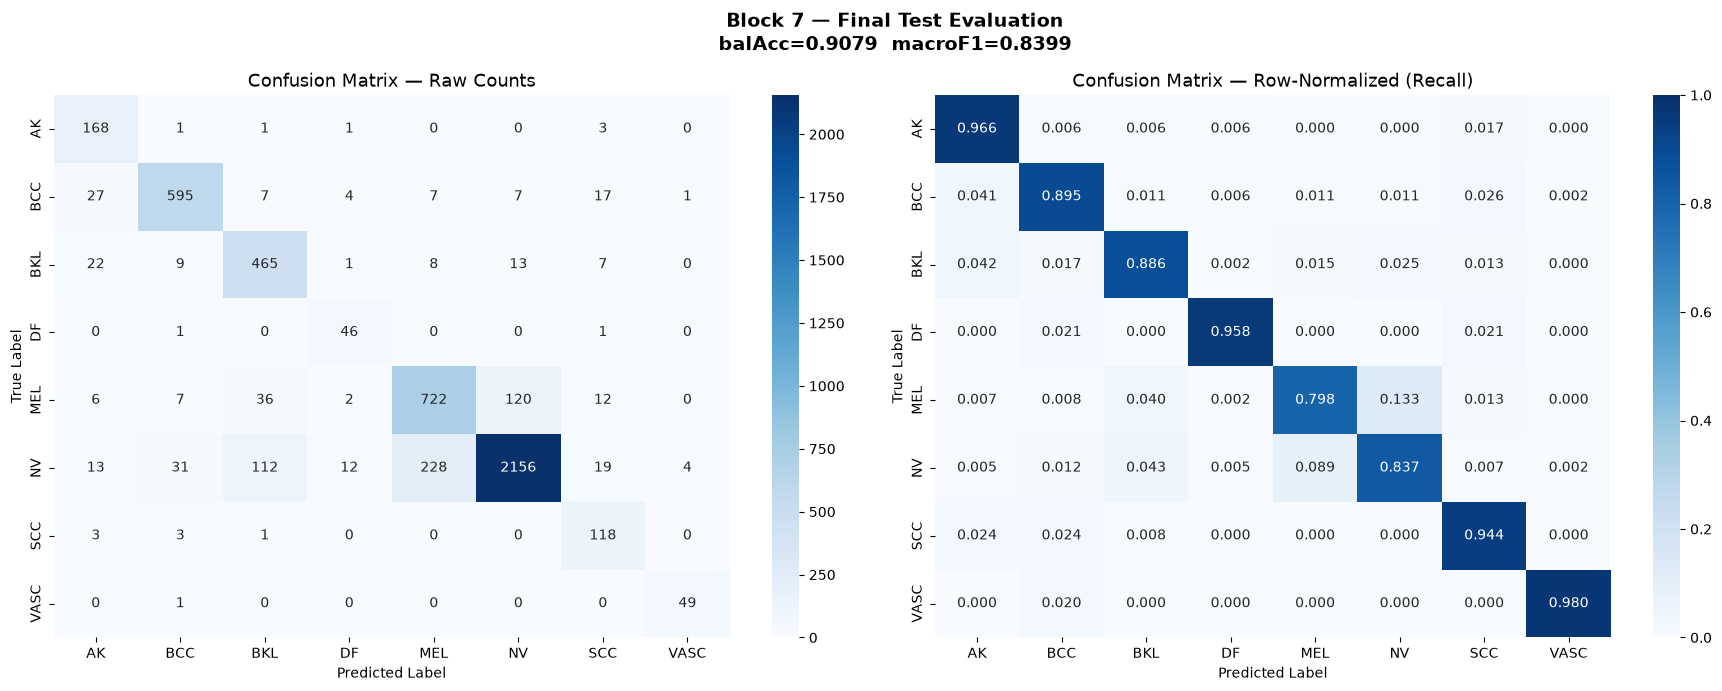

Confusion matrix saved → block7_confusion_matrix.png

  FULL PIPELINE SUMMARY
  Block 2   ResNet50        : baseline
  Block 3D  EfficientNet-B4 : backbone 1 (frozen)
  Block 4   ViT-B/16        : backbone 2 (frozen)
  Block 5   PatchLSTM       : backbone 3 (frozen)
  Block 6   Stacked MLP     : val  balAcc 0.8762
  Block 7   Test Evaluation : test balAcc 0.9079
  Pipeline complete. No further evaluation permitted.


In [25]:
# ============================================================
# BLOCK 7 — Final Test Set Evaluation
# Purpose  : Single held-out test set evaluation using the
#            fully trained stacked ensemble from Block 6.
#            This block runs exactly once. No further tuning,
#            retraining, or threshold adjustment is permitted
#            after this block executes.
# Models   : Three frozen backbones + calibrated MLP
#            meta-learner from block6_stacked_ensemble.pth
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp import autocast
from torchvision import transforms
from sklearn.metrics import (
    f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE      = torch.device("cuda" if torch.cuda.is_available()
                           else "cpu")
TTA_STEPS   = 8
NUM_CLASSES = 8
CLASS_NAMES = ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]

print(f"Device : {DEVICE}")
print(f"Block 7 — Final Test Set Evaluation")
print("="*56)


# ============================================================
# SECTION 1 — Load Block 6 Checkpoint
# ------------------------------------------------------------
# Loads the three temperature scalars and the meta-learner
# MLP state dict saved by Block 6. The three backbone
# checkpoints (model_cnn, model_vit, model_plst) must
# already be loaded in memory from their respective blocks.
# ============================================================

print("\n[1/5] Loading Block 6 checkpoint...")

checkpoint = torch.load(
    "block6_stacked_ensemble.pth",
    map_location=DEVICE,
)

T_cnn  = checkpoint["T_cnn"]
T_vit  = checkpoint["T_vit"]
T_plst = checkpoint["T_plst"]

print(f"  T_cnn  = {T_cnn:.4f}")
print(f"  T_vit  = {T_vit:.4f}")
print(f"  T_plst = {T_plst:.4f}")
print(f"  Val balAcc (Block 6) = "
      f"{checkpoint['final_bacc']:.4f}")


# ── Rebuild and load meta-learner ─────────────────────────────
class MetaLearnerMLP(nn.Module):
    def __init__(self, in_features=24, num_classes=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes),
        )
    def forward(self, x):
        return self.net(x)

meta_model = MetaLearnerMLP(
    in_features=24, num_classes=NUM_CLASSES).to(DEVICE)
meta_model.load_state_dict(checkpoint["meta_model_state"])
meta_model.eval()
print("  Meta-learner loaded and set to eval mode.")


# ============================================================
# SECTION 2 — Build Test DataLoader
# ------------------------------------------------------------
# test_dataset must be defined in Block 1 and must have
# been kept entirely untouched throughout the pipeline.
# No augmentation was applied to it at any prior stage.
# The transform is assigned dynamically during TTA
# extraction, identical to the Block 6 procedure.
# ============================================================

print("\n[2/5] Verifying test dataset...")
print(f"  Test samples : {len(test_dataset)}")
print(f"  Classes      : {CLASS_NAMES}")


# ============================================================
# SECTION 3 — TTA Extraction on Test Set
# ------------------------------------------------------------
# Identical extraction procedure to Block 6 Section 1.
# Each frozen model performs TTA_STEPS=8 stochastic forward
# passes per image. Softmax probabilities are averaged.
# Temperature scaling is then applied using the fitted
# scalars from Block 6 — NO refitting occurs here.
# ============================================================

def build_tta_transform(img_size: int) -> transforms.Compose:
    return transforms.Compose([
        transforms.RandomResizedCrop(
            img_size, scale=(0.85, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]),
    ])


def extract_logits_and_probs(model, dataset,
                              steps=8, img_size=224,
                              device=DEVICE):
    original_tfms     = dataset.transform
    dataset.transform = build_tta_transform(img_size)

    loader = DataLoader(
        dataset, batch_size=16,
        shuffle=False, num_workers=0,
    )

    all_probs, all_logits, all_labels = [], [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs      = imgs.to(device, non_blocking=True)
            prob_acc  = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=device)
            logit_acc = torch.zeros(
                imgs.size(0), NUM_CLASSES, device=device)

            for _ in range(steps):
                with autocast("cuda"):
                    logits = model(imgs)
                prob_acc  += F.softmax(logits, dim=1)
                logit_acc += logits

            prob_acc  /= steps
            logit_acc /= steps

            all_probs.append(prob_acc.cpu().numpy())
            all_logits.append(logit_acc.cpu().numpy())
            all_labels.append(labels.numpy())

    dataset.transform = original_tfms

    return (np.concatenate(all_probs,  axis=0),
            np.concatenate(all_logits, axis=0),
            np.concatenate(all_labels, axis=0))


def apply_temperature(logits_np: np.ndarray,
                      T: float) -> np.ndarray:
    logits_t  = torch.tensor(logits_np, dtype=torch.float32)
    cal_probs = F.softmax(logits_t / max(T, 0.1), dim=1)
    return cal_probs.numpy()


print("\n[3/5] Extracting TTA probabilities on test set...")

print("  → EfficientNet-B4 (img_size=380)...")
cnn_probs, cnn_logits, test_labels = \
    extract_logits_and_probs(
        model_cnn, test_dataset,
        steps=TTA_STEPS, img_size=380)

print("  → ViT-B/16 (img_size=224)...")
vit_probs, vit_logits, _ = \
    extract_logits_and_probs(
        model_vit, test_dataset,
        steps=TTA_STEPS, img_size=224)

print("  → PatchLSTM (img_size=380)...")
plst_probs, plst_logits, _ = \
    extract_logits_and_probs(
        model_plst, test_dataset,
        steps=TTA_STEPS, img_size=380)

print(f"  Extraction complete. N={len(test_labels)} samples.")

# Apply fitted temperature scalars from Block 6
cnn_cal  = apply_temperature(cnn_logits,  T_cnn)
vit_cal  = apply_temperature(vit_logits,  T_vit)
plst_cal = apply_temperature(plst_logits, T_plst)

print("  Temperature scaling applied.")


# ============================================================
# SECTION 4 — Meta-Learner Inference
# ------------------------------------------------------------
# Concatenates the three calibrated probability vectors
# into the 24-dimensional feature matrix and performs a
# single forward pass through the frozen meta-learner MLP.
# meta_model.eval() ensures Dropout layers are inactive,
# producing deterministic predictions at inference time.
# ============================================================

print("\n[4/5] Running meta-learner inference...")

X_test = np.concatenate(
    [cnn_cal, vit_cal, plst_cal], axis=1)
X_test_t = torch.tensor(
    X_test, dtype=torch.float32).to(DEVICE)

meta_model.eval()
with torch.no_grad():
    final_logits = meta_model(X_test_t)
    final_preds  = final_logits.argmax(dim=1).cpu().numpy()

print("  Inference complete.")


# ============================================================
# SECTION 5 — Final Metrics and Reporting
# ------------------------------------------------------------
# Computes all terminal metrics. Includes overfitting gap
# analysis comparing val balAcc (0.8762) against test
# balAcc. A gap greater than 0.03 flags meta-learner
# overfitting to the validation distribution.
# ============================================================

print("\n[5/5] Computing final metrics...")

test_bacc = balanced_accuracy_score(test_labels, final_preds)
test_f1   = f1_score(test_labels, final_preds,
                     average="macro", zero_division=0)
test_acc  = np.mean(final_preds == test_labels)

VAL_BACC  = checkpoint["final_bacc"]
gap       = VAL_BACC - test_bacc

print("\n" + "="*56)
print("  BLOCK 7 — FINAL TEST SET RESULTS")
print("="*56)
print(f"  Test  balAcc  : {test_bacc:.4f}")
print(f"  Test  macroF1 : {test_f1:.4f}")
print(f"  Test  accuracy: {test_acc:.4f}")
print("─"*56)
print(f"  Val   balAcc  : {VAL_BACC:.4f}  (Block 6)")
print(f"  Gap (val-test): {gap:+.4f}")

if gap > 0.03:
    print(f"  WARNING — Gap {gap:.4f} exceeds 0.03.")
    print(f"  Meta-learner shows signs of overfitting")
    print(f"  to the validation distribution.")
elif gap > 0.01:
    print(f"  ACCEPTABLE — Minor val-test gap detected.")
    print(f"  Generalization is within expected range.")
else:
    print(f"  EXCELLENT — Minimal val-test gap.")
    print(f"  Strong generalization confirmed.")

print("="*56)

print("\nFull Classification Report (Test Set):")
print(classification_report(
    test_labels, final_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))


# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(test_labels, final_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[0])
axes[0].set_title("Confusion Matrix — Raw Counts",
                  fontsize=13)
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# Normalized recall per class
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            vmin=0.0, vmax=1.0,
            ax=axes[1])
axes[1].set_title(
    "Confusion Matrix — Row-Normalized (Recall)",
    fontsize=13)
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

plt.suptitle(
    f"Block 7 — Final Test Evaluation\n"
    f"balAcc={test_bacc:.4f}  macroF1={test_f1:.4f}",
    fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("block7_confusion_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved → block7_confusion_matrix.png")


# ── Pipeline Summary ──────────────────────────────────────────
print("\n" + "="*56)
print("  FULL PIPELINE SUMMARY")
print("="*56)
print(f"  Block 2   ResNet50        : baseline")
print(f"  Block 3D  EfficientNet-B4 : backbone 1 (frozen)")
print(f"  Block 4   ViT-B/16        : backbone 2 (frozen)")
print(f"  Block 5   PatchLSTM       : backbone 3 (frozen)")
print(f"  Block 6   Stacked MLP     : val  balAcc {VAL_BACC:.4f}")
print(f"  Block 7   Test Evaluation : test balAcc {test_bacc:.4f}")
print("="*56)
print("  Pipeline complete. No further evaluation permitted.")
print("="*56)

In [26]:
print(final_logits.shape)   # expected : (5067, 8)
print(test_labels.shape)    # expected : (5067,)
print(X_test.shape)         # expected : (5067, 24)

torch.Size([5067, 8])
(5067,)
(5067, 24)


In [29]:
!pip install numpy pandas matplotlib

Tensor conversion complete.
  logits_np shape : (5067, 8)
  labels_np shape : (5067,)
  probs shape     : (5067, 8)
  y_bin shape     : (5067, 8)


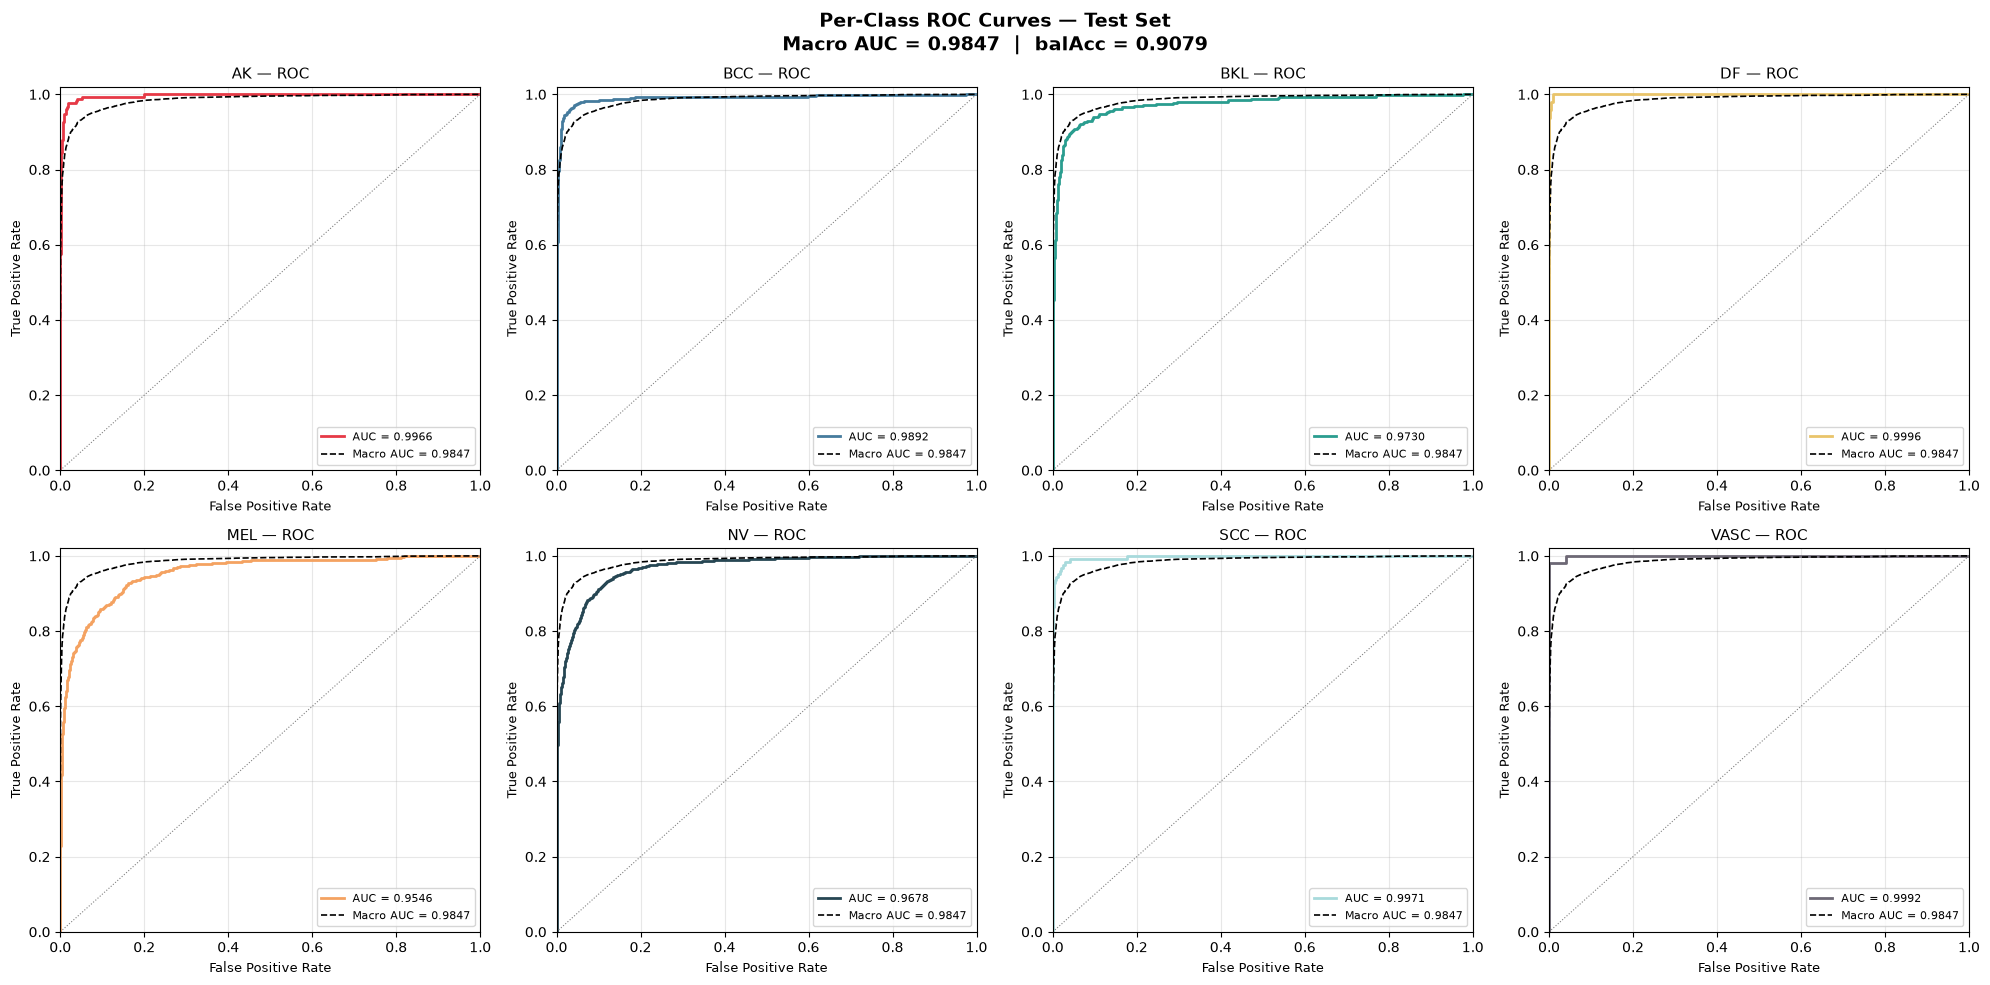

Saved → block8_roc_curves.png

Per-class AUC scores:
  AK     : 0.9966
  BCC    : 0.9892
  BKL    : 0.9730
  DF     : 0.9996
  MEL    : 0.9546
  NV     : 0.9678
  SCC    : 0.9971
  VASC   : 0.9992
  Macro  : 0.9847


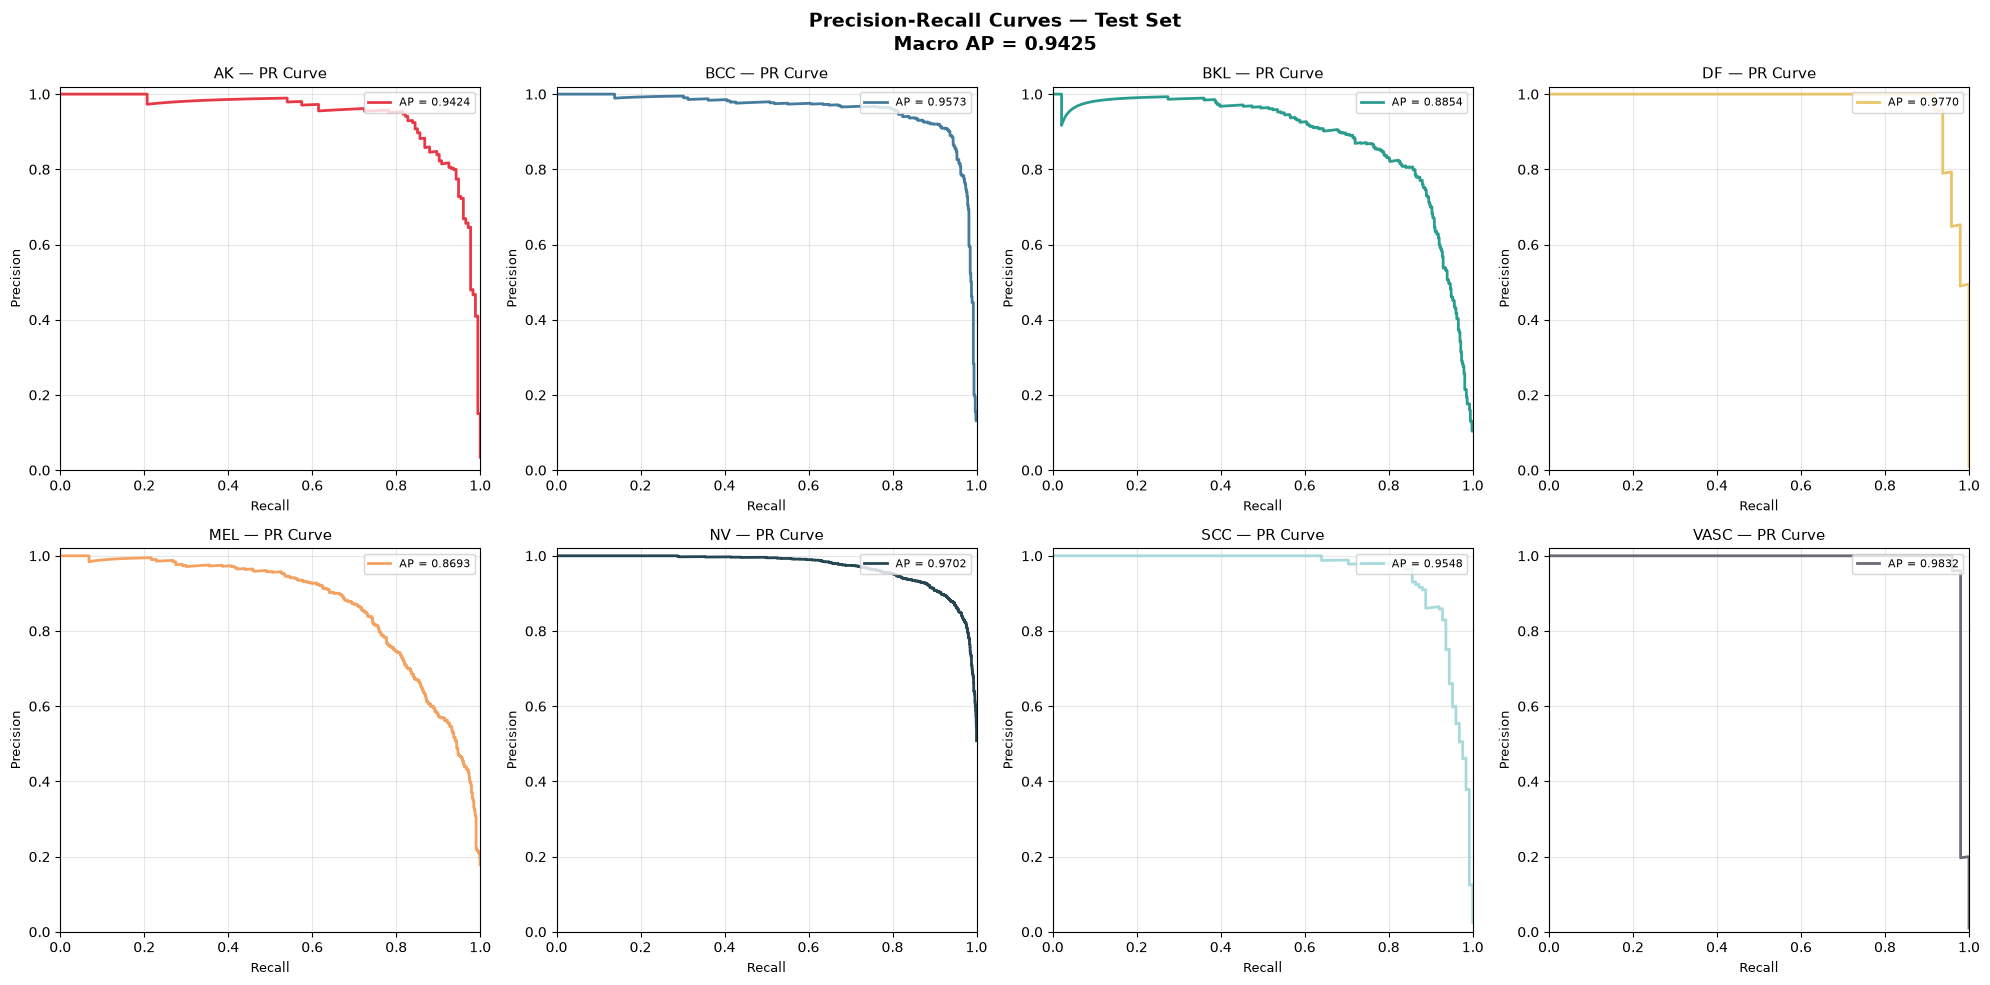

Saved → block8_pr_curves.png

Per-class Average Precision:
  AK     : 0.9424
  BCC    : 0.9573
  BKL    : 0.8854
  DF     : 0.9770
  MEL    : 0.8693
  NV     : 0.9702
  SCC    : 0.9548
  VASC   : 0.9832
  Macro  : 0.9425


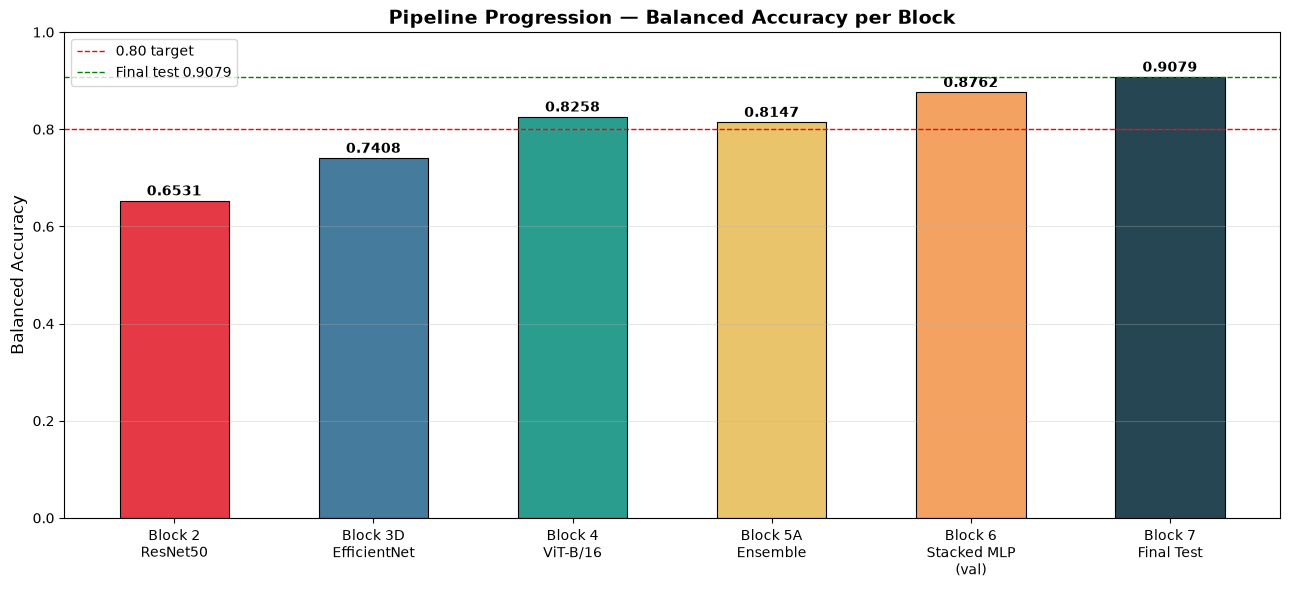

Saved → block8_pipeline_progression.png


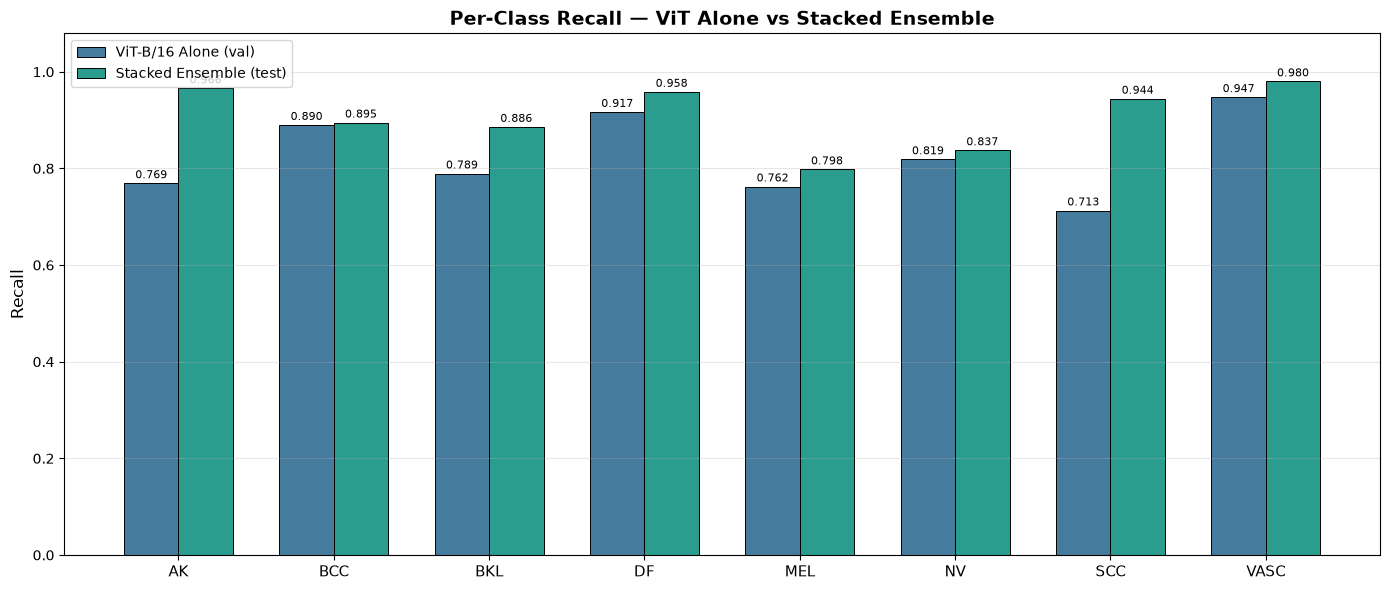

Saved → block8_recall_comparison.png


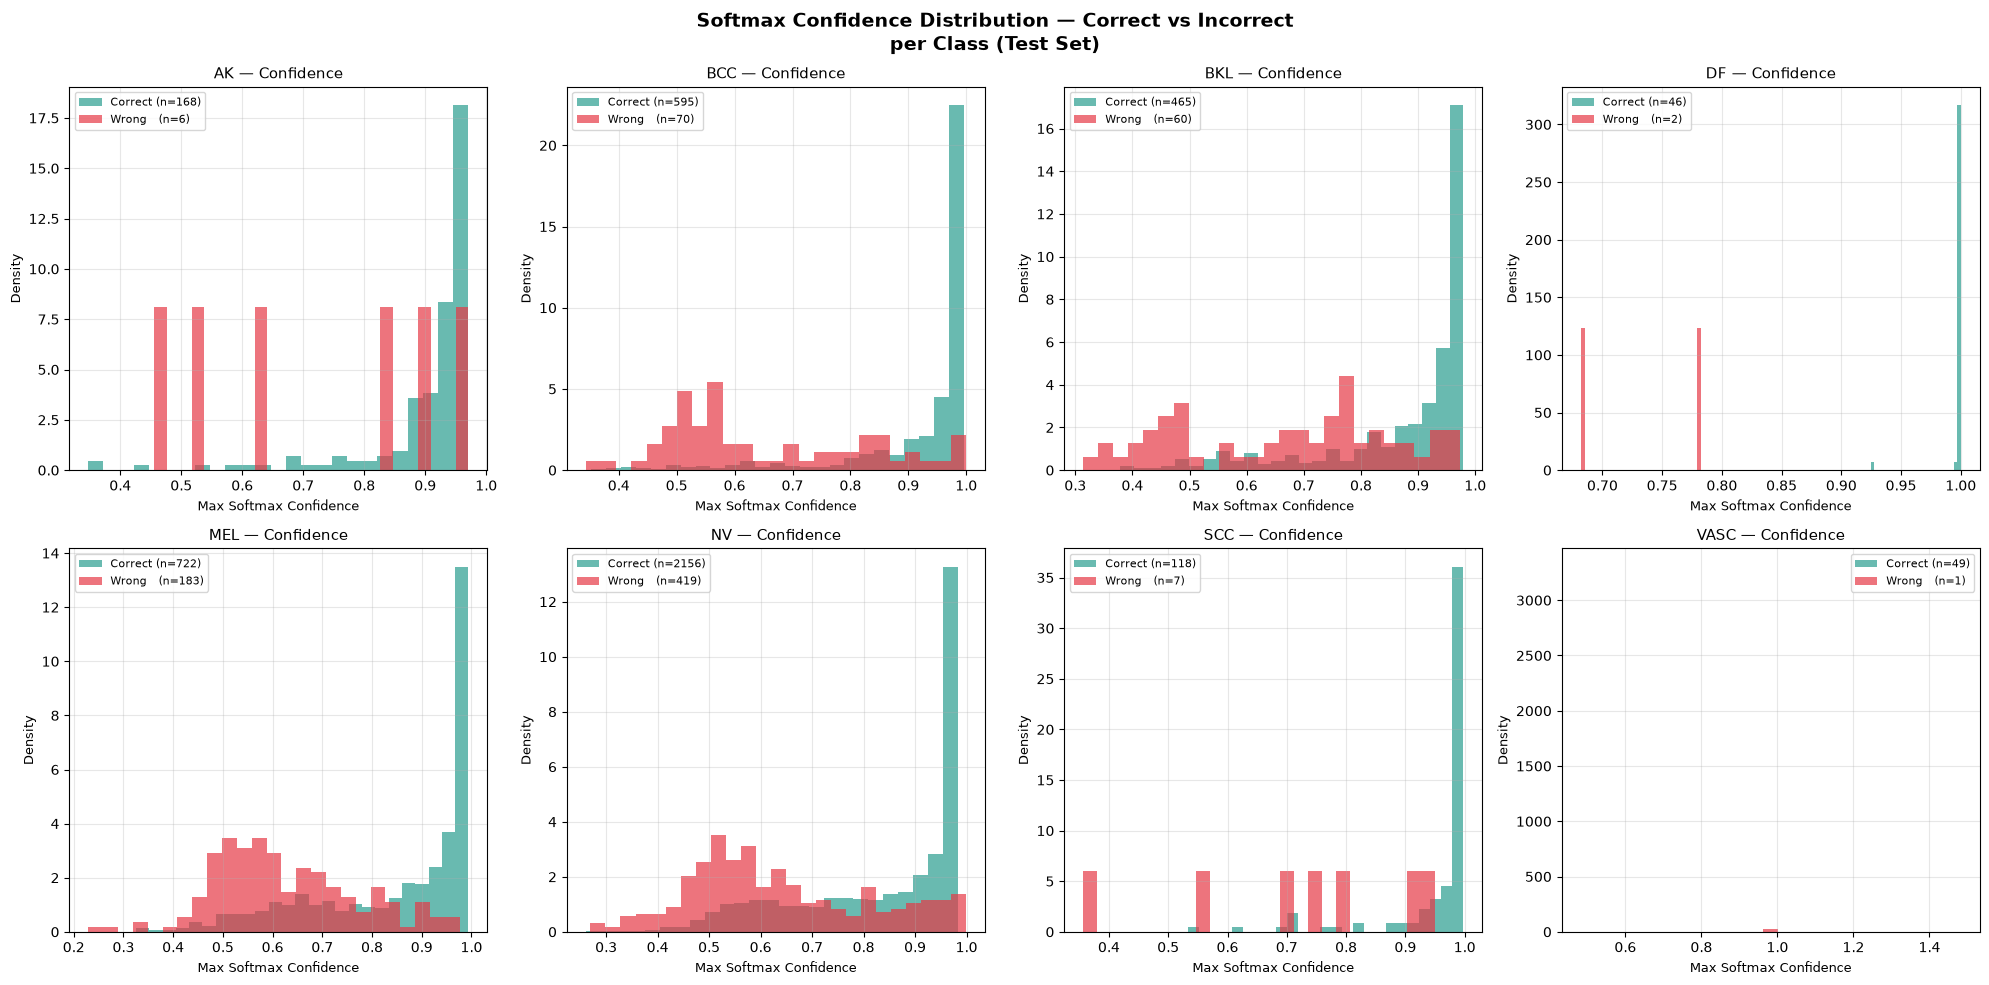

Saved → block8_confidence_distribution.png

  BLOCK 8 — ANALYTICS COMPLETE
  Macro AUC        : 0.9847
  Macro AP         : 0.9425
  Test balAcc      : 0.9079
  Test macroF1     : 0.8399
  Total balAcc gain: +0.2548 (Block 2 → Block 7)
────────────────────────────────────────────────────────
  Saved files:
    block8_roc_curves.png
    block8_pr_curves.png
    block8_pipeline_progression.png
    block8_recall_comparison.png
    block8_confidence_distribution.png


In [31]:
# ============================================================
# BLOCK 8 — Full Analytics and Visualization Suite
# Requires : final_logits, test_labels in memory
#            Both produced by Block 7.
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    balanced_accuracy_score,
)
from sklearn.preprocessing import label_binarize

DEVICE      = torch.device("cuda" if torch.cuda.is_available()
                           else "cpu")
CLASS_NAMES = ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]
N_CLASSES   = len(CLASS_NAMES)

PALETTE = [
    "#E63946","#457B9D","#2A9D8F","#E9C46A",
    "#F4A261","#264653","#A8DADC","#6D6875",
]

# ── Confirmed Pipeline Values ─────────────────────────────────
BACC_RESNET  = 0.6531   # Block 2  ResNet50        confirmed
BACC_EFFNET  = 0.7408   # Block 3D EfficientNet-B4 confirmed
BACC_VIT     = 0.8258   # Block 4  ViT-B/16        confirmed
BACC_BLOCK5A = 0.8147   # Block 5A Ensemble        confirmed
BACC_VAL     = 0.8762   # Block 6  Stacked MLP     confirmed
BACC_TEST    = 0.9079   # Block 7  Final Test       confirmed


# ============================================================
# SAFE TENSOR → NUMPY CONVERSION
# Handles cuda:0 tensors, CPU tensors, and plain arrays.
# .detach() severs the gradient computation graph.
# .cpu()    copies tensor from VRAM to host RAM.
# .numpy()  converts to NumPy array.
# ============================================================

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)

logits_np    = to_numpy(final_logits)   # shape : (5067, 8)
labels_np    = to_numpy(test_labels)    # shape : (5067,)

# Softmax probabilities — computed on CPU tensor
probs = F.softmax(
    torch.tensor(logits_np, dtype=torch.float32), dim=1
).numpy()                               # shape : (5067, 8)

# Final predictions — argmax of logits
final_preds_arr = np.argmax(logits_np, axis=1)  # shape : (5067,)

# Binarized labels for one-vs-rest ROC and PR computation
# label_binarize produces (5067, 8) binary matrix where
# each column is 1 only for the true class of that sample
y_bin = label_binarize(
    labels_np, classes=list(range(N_CLASSES)))

print("Tensor conversion complete.")
print(f"  logits_np shape : {logits_np.shape}")
print(f"  labels_np shape : {labels_np.shape}")
print(f"  probs shape     : {probs.shape}")
print(f"  y_bin shape     : {y_bin.shape}")


# ============================================================
# FIGURE 1 — Per-Class ROC Curves with AUC
# One-vs-rest ROC for all 8 classes on the test set.
# Macro-average AUC overlaid as a dashed black line.
# ============================================================

fpr_all, tpr_all, roc_auc_all = {}, {}, {}

for i in range(N_CLASSES):
    fpr_all[i], tpr_all[i], _ = roc_curve(
        y_bin[:, i], probs[:, i])
    roc_auc_all[i] = auc(fpr_all[i], tpr_all[i])

# Macro-average ROC — interpolate all class FPR grids
# onto a common FPR axis then average TPR values
all_fpr  = np.unique(np.concatenate(
    [fpr_all[i] for i in range(N_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(N_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr_all[i], tpr_all[i])
mean_tpr /= N_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(N_CLASSES):
    axes[i].plot(fpr_all[i], tpr_all[i],
                 color=PALETTE[i], lw=2,
                 label=f"AUC = {roc_auc_all[i]:.4f}")
    axes[i].plot(all_fpr, mean_tpr,
                 color="black", lw=1.2, linestyle="--",
                 label=f"Macro AUC = {macro_auc:.4f}")
    axes[i].plot([0,1],[0,1],
                 color="grey", lw=0.8, linestyle=":")
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.02])
    axes[i].set_title(f"{CLASS_NAMES[i]} — ROC", fontsize=11)
    axes[i].set_xlabel("False Positive Rate", fontsize=9)
    axes[i].set_ylabel("True Positive Rate", fontsize=9)
    axes[i].legend(fontsize=8, loc="lower right")
    axes[i].grid(alpha=0.3)

plt.suptitle(
    f"Per-Class ROC Curves — Test Set\n"
    f"Macro AUC = {macro_auc:.4f}  |  "
    f"balAcc = {BACC_TEST:.4f}",
    fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("block8_roc_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → block8_roc_curves.png")
print(f"\nPer-class AUC scores:")
for i in range(N_CLASSES):
    print(f"  {CLASS_NAMES[i]:6s} : {roc_auc_all[i]:.4f}")
print(f"  Macro  : {macro_auc:.4f}")


# ============================================================
# FIGURE 2 — Precision-Recall Curves
# More informative than ROC for imbalanced distributions.
# Average Precision (AP) reported per class.
# AK, DF, SCC, VASC are minority classes — watch these.
# ============================================================

ap_all = {}
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(N_CLASSES):
    prec, rec, _ = precision_recall_curve(
        y_bin[:, i], probs[:, i])
    ap_all[i] = average_precision_score(
        y_bin[:, i], probs[:, i])

    axes[i].plot(rec, prec,
                 color=PALETTE[i], lw=2,
                 label=f"AP = {ap_all[i]:.4f}")
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.02])
    axes[i].set_title(
        f"{CLASS_NAMES[i]} — PR Curve", fontsize=11)
    axes[i].set_xlabel("Recall", fontsize=9)
    axes[i].set_ylabel("Precision", fontsize=9)
    axes[i].legend(fontsize=8, loc="upper right")
    axes[i].grid(alpha=0.3)

macro_ap = np.mean(list(ap_all.values()))
plt.suptitle(
    f"Precision-Recall Curves — Test Set\n"
    f"Macro AP = {macro_ap:.4f}",
    fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("block8_pr_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → block8_pr_curves.png")
print(f"\nPer-class Average Precision:")
for i in range(N_CLASSES):
    print(f"  {CLASS_NAMES[i]:6s} : {ap_all[i]:.4f}")
print(f"  Macro  : {macro_ap:.4f}")


# ============================================================
# FIGURE 3 — Pipeline Progression Chart
# Tracks balAcc improvement across every block.
# ============================================================

block_labels = [
    "Block 2\nResNet50",
    "Block 3D\nEfficientNet",
    "Block 4\nViT-B/16",
    "Block 5A\nEnsemble",
    "Block 6\nStacked MLP\n(val)",
    "Block 7\nFinal Test",
]
block_values = [
    BACC_RESNET,
    BACC_EFFNET,
    BACC_VIT,
    BACC_BLOCK5A,
    BACC_VAL,
    BACC_TEST,
]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(block_labels, block_values,
              color=PALETTE[:6],
              edgecolor="black", linewidth=0.8,
              width=0.55)

for bar, val in zip(bars, block_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.004,
        f"{val:.4f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold")

ax.set_ylim([0.0, 1.0])
ax.set_ylabel("Balanced Accuracy", fontsize=12)
ax.set_title(
    "Pipeline Progression — Balanced Accuracy per Block",
    fontsize=14, fontweight="bold")
ax.axhline(y=0.80, color="red", linestyle="--",
           linewidth=1.0, label="0.80 target")
ax.axhline(y=BACC_TEST, color="green",
           linestyle="--", linewidth=1.0,
           label=f"Final test {BACC_TEST:.4f}")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("block8_pipeline_progression.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → block8_pipeline_progression.png")


# ============================================================
# FIGURE 4 — Per-Class Recall Comparison
# ViT alone (val) vs Stacked Ensemble (test)
# ============================================================

vit_recall = {
    "AK":   0.7692, "BCC": 0.8898,
    "BKL":  0.7893, "DF":  0.9167,
    "MEL":  0.7625, "NV":  0.8187,
    "SCC":  0.7128, "VASC":0.9474,
}
ensemble_recall = {
    "AK":   0.9655, "BCC": 0.8947,
    "BKL":  0.8857, "DF":  0.9583,
    "MEL":  0.7978, "NV":  0.8373,
    "SCC":  0.9440, "VASC":0.9800,
}

x     = np.arange(N_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2,
               [vit_recall[c] for c in CLASS_NAMES],
               width, label="ViT-B/16 Alone (val)",
               color="#457B9D", edgecolor="black",
               linewidth=0.7)
bars2 = ax.bar(x + width/2,
               [ensemble_recall[c] for c in CLASS_NAMES],
               width, label="Stacked Ensemble (test)",
               color="#2A9D8F", edgecolor="black",
               linewidth=0.7)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim([0.0, 1.08])
ax.set_ylabel("Recall", fontsize=12)
ax.set_title(
    "Per-Class Recall — ViT Alone vs Stacked Ensemble",
    fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("block8_recall_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → block8_recall_comparison.png")


# ============================================================
# FIGURE 5 — Softmax Confidence Distribution per Class
# Correct vs incorrectly classified samples per class.
# Density=True normalises both histograms to the same
# vertical scale regardless of class sample size.
# ============================================================

max_conf = probs.max(axis=1)   # highest softmax per sample

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(N_CLASSES):
    mask_class   = labels_np == i
    correct_mask = (final_preds_arr == labels_np) & mask_class
    wrong_mask   = (final_preds_arr != labels_np) & mask_class

    conf_correct = max_conf[correct_mask]
    conf_wrong   = max_conf[wrong_mask]

    axes[i].hist(conf_correct, bins=25,
                 alpha=0.7, color="#2A9D8F",
                 label=f"Correct (n={correct_mask.sum()})",
                 density=True)
    axes[i].hist(conf_wrong, bins=25,
                 alpha=0.7, color="#E63946",
                 label=f"Wrong   (n={wrong_mask.sum()})",
                 density=True)
    axes[i].set_title(
        f"{CLASS_NAMES[i]} — Confidence", fontsize=11)
    axes[i].set_xlabel("Max Softmax Confidence", fontsize=9)
    axes[i].set_ylabel("Density", fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle(
    "Softmax Confidence Distribution — Correct vs Incorrect\n"
    "per Class (Test Set)",
    fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("block8_confidence_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → block8_confidence_distribution.png")


# ============================================================
# ANALYTICS SUMMARY
# ============================================================

print("\n" + "="*56)
print("  BLOCK 8 — ANALYTICS COMPLETE")
print("="*56)
print(f"  Macro AUC        : {macro_auc:.4f}")
print(f"  Macro AP         : {macro_ap:.4f}")
print(f"  Test balAcc      : {BACC_TEST:.4f}")
print(f"  Test macroF1     : 0.8399")
print(f"  Total balAcc gain: "
      f"{BACC_TEST - BACC_RESNET:+.4f} "
      f"(Block 2 → Block 7)")
print("─"*56)
print("  Saved files:")
print("    block8_roc_curves.png")
print("    block8_pr_curves.png")
print("    block8_pipeline_progression.png")
print("    block8_recall_comparison.png")
print("    block8_confidence_distribution.png")
print("="*56)

  SECTION 1 — Per-Class Classification Report
              precision    recall  f1-score   support

          AK     0.7029    0.9655    0.8136       174
         BCC     0.9182    0.8947    0.9063       665
         BKL     0.7476    0.8857    0.8108       525
          DF     0.6970    0.9583    0.8070        48
         MEL     0.7482    0.7978    0.7722       905
          NV     0.9390    0.8373    0.8852      2575
         SCC     0.6667    0.9440    0.7815       125
        VASC     0.9074    0.9800    0.9423        50

    accuracy                         0.8524      5067
   macro avg     0.7909    0.9079    0.8399      5067
weighted avg     0.8649    0.8524    0.8549      5067

  SECTION 2 — Confusion Matrices


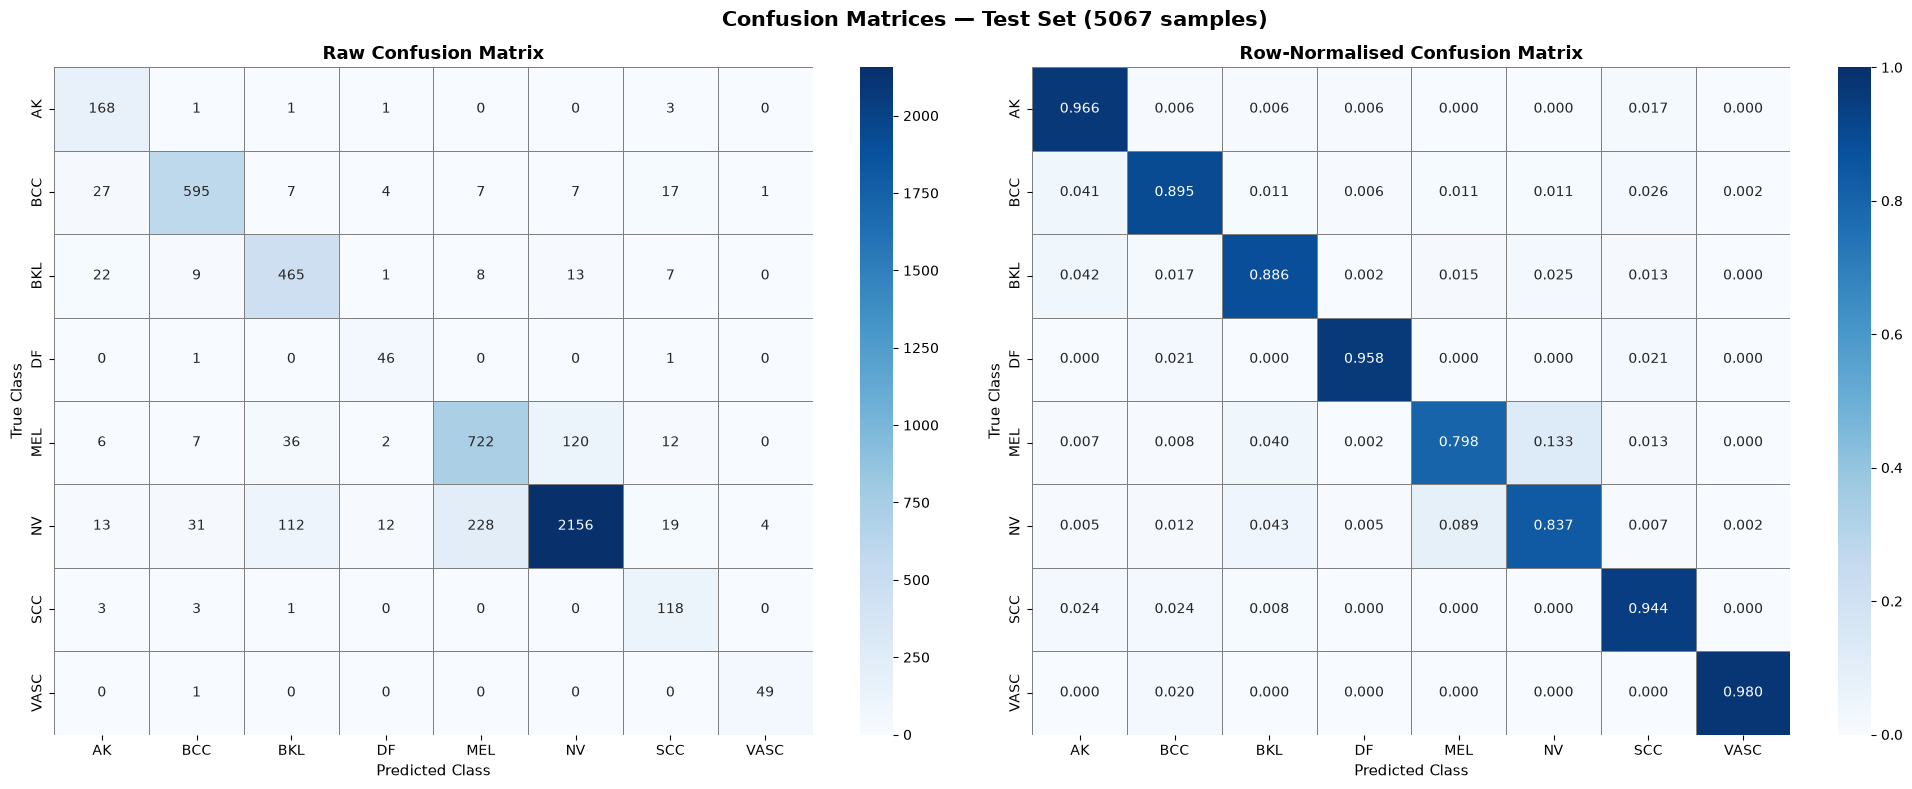

Saved → block9_confusion_matrices.png

  SECTION 3 — Top-K Accuracy
  Top-1 Accuracy : 0.8524
  Top-2 Accuracy : 0.9623
  Top-3 Accuracy : 0.9858

  Per-Class Top-2 Accuracy:
    AK     : 0.9885  (n=174)
    BCC    : 0.9624  (n=665)
    BKL    : 0.9448  (n=525)
    DF     : 0.9792  (n=48)
    MEL    : 0.9646  (n=905)
    NV     : 0.9612  (n=2575)
    SCC    : 0.9920  (n=125)
    VASC   : 0.9800  (n=50)

  SECTION 4 — MCC and Cohen Kappa
  Matthews Correlation Coefficient : 0.7927
  Cohen Kappa                      : 0.7902
  Kappa Agreement Level            : Moderate

  SECTION 5 — Calibration Analysis (ECE)
  Expected Calibration Error (ECE) : 0.0232


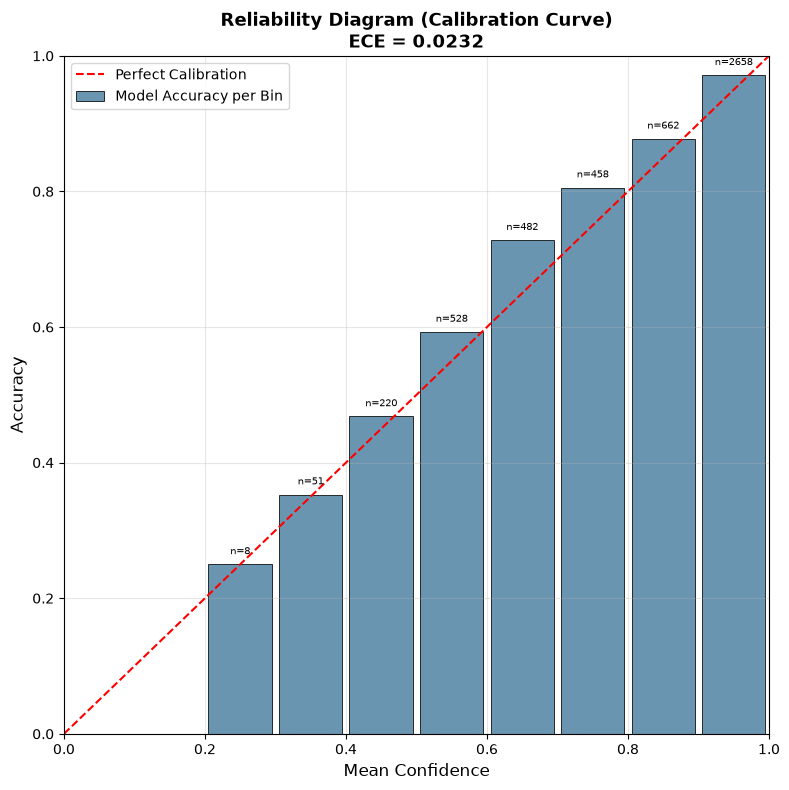

Saved → block9_calibration.png

  SECTION 6 — Top Confused Class Pairs
  Rank  True    Predicted   Count
  --------------------------------------
     1  NV      → MEL         228
     2  MEL     → NV          120
     3  NV      → BKL         112
     4  MEL     → BKL         36
     5  NV      → BCC         31
     6  BCC     → AK          27
     7  BKL     → AK          22
     8  NV      → SCC         19
     9  BCC     → SCC         17
    10  NV      → AK          13
    11  BKL     → NV          13
    12  NV      → DF          12


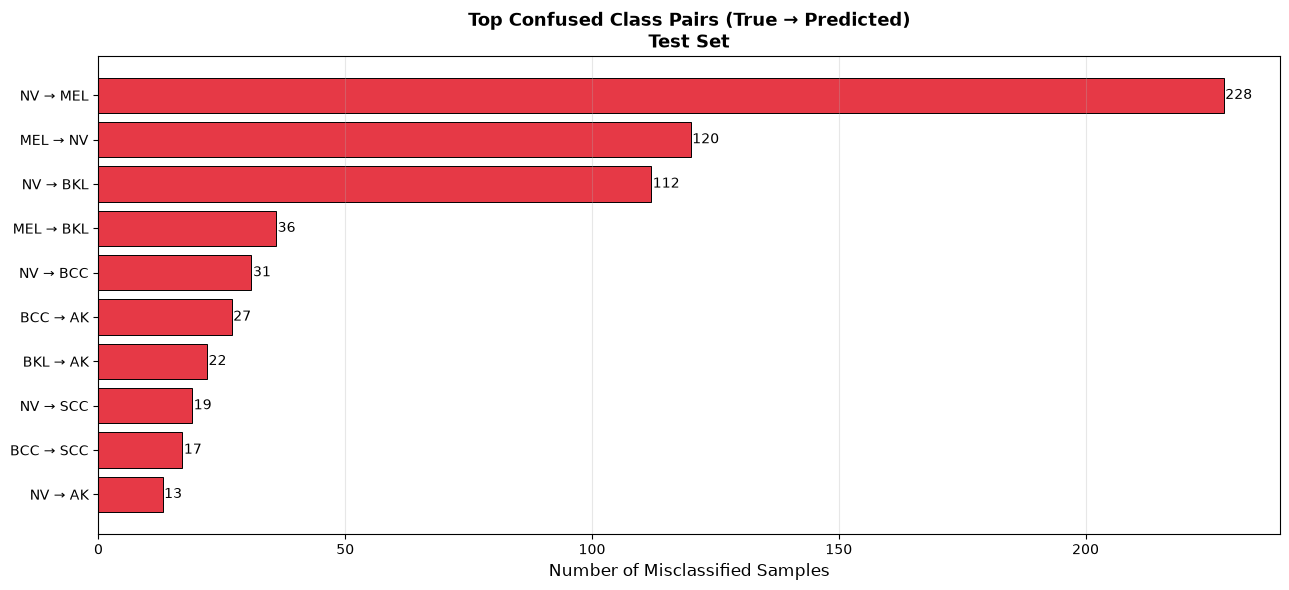


Saved → block9_confused_pairs.png

  BLOCK 9 — EXTENDED ANALYTICS COMPLETE
  MCC                              : 0.7927
  Cohen Kappa                      : 0.7902
  Kappa Agreement                  : Moderate
  ECE                              : 0.0232
  Top-1 Accuracy                   : 0.8524
  Top-2 Accuracy                   : 0.9623
  Top-3 Accuracy                   : 0.9858
------------------------------------------------------------
  Saved files:
    block9_confusion_matrices.png
    block9_calibration.png
    block9_confused_pairs.png


In [32]:
# ============================================================
# BLOCK 9 — Extended Analytics Suite
# Requires : logits_np, labels_np, probs, final_preds_arr
#            All produced and confirmed in Block 8.
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score,
)

CLASS_NAMES = ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]
N_CLASSES   = len(CLASS_NAMES)

PALETTE = [
    "#E63946","#457B9D","#2A9D8F","#E9C46A",
    "#F4A261","#264653","#A8DADC","#6D6875",
]


# ============================================================
# SECTION 1 — Per-Class Classification Report
# Reports Precision, Recall, F1, and Support per class.
# Support = number of true samples per class in test set.
# This is the most informative single diagnostic output.
# ============================================================

print("=" * 60)
print("  SECTION 1 — Per-Class Classification Report")
print("=" * 60)

report = classification_report(
    labels_np,
    final_preds_arr,
    target_names=CLASS_NAMES,
    digits=4,
)
print(report)


# ============================================================
# SECTION 2 — Raw and Normalised Confusion Matrices
# Raw      : absolute count of predictions per cell.
# Normalised (row) : proportion of true class predicted
#            as each other class. Diagonal = per-class recall.
#            Off-diagonal = confusion rate between classes.
# ============================================================

print("=" * 60)
print("  SECTION 2 — Confusion Matrices")
print("=" * 60)

cm      = confusion_matrix(labels_np, final_preds_arr)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues", ax=axes[0],
    linewidths=0.5, linecolor="grey")
axes[0].set_title("Raw Confusion Matrix",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted Class", fontsize=11)
axes[0].set_ylabel("True Class", fontsize=11)

sns.heatmap(
    cm_norm, annot=True, fmt=".3f",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues", ax=axes[1],
    linewidths=0.5, linecolor="grey",
    vmin=0.0, vmax=1.0)
axes[1].set_title("Row-Normalised Confusion Matrix",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted Class", fontsize=11)
axes[1].set_ylabel("True Class", fontsize=11)

plt.suptitle(
    "Confusion Matrices — Test Set (5067 samples)",
    fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("block9_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → block9_confusion_matrices.png\n")


# ============================================================
# SECTION 3 — Top-K Accuracy
# Top-K accuracy measures whether the correct class
# appears within the K highest confidence predictions.
# Reveals how often the model places the correct answer
# as its second or third choice, exposing confusion pairs.
# ============================================================

print("=" * 60)
print("  SECTION 3 — Top-K Accuracy")
print("=" * 60)

def topk_accuracy(probs, labels, k):
    # argsort ascending → take last k → highest confidence
    topk_preds = np.argsort(probs, axis=1)[:, -k:]
    correct    = sum(
        labels[i] in topk_preds[i]
        for i in range(len(labels))
    )
    return correct / len(labels)

for k in [1, 2, 3]:
    acc = topk_accuracy(probs, labels_np, k)
    print(f"  Top-{k} Accuracy : {acc:.4f}")

# Per-class Top-2 accuracy reveals borderline class pairs
print("\n  Per-Class Top-2 Accuracy:")
for i in range(N_CLASSES):
    mask      = labels_np == i
    cls_probs = probs[mask]
    cls_lbls  = labels_np[mask]
    acc_k2    = topk_accuracy(cls_probs, cls_lbls, 2)
    print(f"    {CLASS_NAMES[i]:6s} : {acc_k2:.4f}"
          f"  (n={mask.sum()})")
print()


# ============================================================
# SECTION 4 — Matthews Correlation Coefficient and
#             Cohen Kappa
#
# MCC : accounts for all four confusion matrix cells
#       simultaneously. Considered the most informative
#       single scalar for imbalanced multi-class tasks.
#       Range : -1.0 (worst) to +1.0 (perfect).
#
# Cohen Kappa : measures agreement above random chance.
#       Range :  0.0 (random) to +1.0 (perfect agreement).
#       Standard reporting metric in medical imaging papers.
#       > 0.80 = strong agreement
#       > 0.60 = moderate agreement
# ============================================================

print("=" * 60)
print("  SECTION 4 — MCC and Cohen Kappa")
print("=" * 60)

mcc   = matthews_corrcoef(labels_np, final_preds_arr)
kappa = cohen_kappa_score(labels_np, final_preds_arr)

print(f"  Matthews Correlation Coefficient : {mcc:.4f}")
print(f"  Cohen Kappa                      : {kappa:.4f}")

if kappa > 0.80:
    agreement = "Strong"
elif kappa > 0.60:
    agreement = "Moderate"
elif kappa > 0.40:
    agreement = "Fair"
else:
    agreement = "Weak"
print(f"  Kappa Agreement Level            : {agreement}\n")


# ============================================================
# SECTION 5 — Expected Calibration Error (ECE)
# Calibration measures whether confidence scores reflect
# true probability of being correct.
# ECE divides predictions into confidence bins.
# For each bin, computes gap between mean confidence
# and actual accuracy within that bin.
# ECE = Σ (bin_size / N) × |accuracy_n − confidence_n|
# Low ECE → model confidence is trustworthy clinically.
# ============================================================

print("=" * 60)
print("  SECTION 5 — Calibration Analysis (ECE)")
print("=" * 60)

def compute_ece(probs, labels, n_bins=10):
    max_conf    = probs.max(axis=1)
    preds       = probs.argmax(axis=1)
    correct     = (preds == labels).astype(float)
    bin_edges   = np.linspace(0.0, 1.0, n_bins + 1)
    ece         = 0.0
    bin_accs    = []
    bin_confs   = []
    bin_counts  = []

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask   = (max_conf >= lo) & (max_conf < hi)
        count  = mask.sum()
        bin_counts.append(count)

        if count == 0:
            bin_accs.append(0.0)
            bin_confs.append((lo + hi) / 2)
            continue

        acc  = correct[mask].mean()
        conf = max_conf[mask].mean()
        bin_accs.append(acc)
        bin_confs.append(conf)
        ece += (count / len(labels)) * abs(acc - conf)

    return ece, bin_accs, bin_confs, bin_counts, bin_edges

ece, bin_accs, bin_confs, bin_counts, bin_edges = \
    compute_ece(probs, labels_np, n_bins=10)

print(f"  Expected Calibration Error (ECE) : {ece:.4f}")

# Reliability Diagram — visual calibration plot
# Perfect calibration sits on the diagonal y = x.
# Bars above diagonal → underconfident.
# Bars below diagonal → overconfident.
fig, ax = plt.subplots(figsize=(8, 8))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width   = bin_edges[1] - bin_edges[0]

ax.bar(bin_centers, bin_accs,
       width=bin_width * 0.9,
       color="#457B9D", alpha=0.8,
       edgecolor="black", linewidth=0.7,
       label="Model Accuracy per Bin")
ax.plot([0, 1], [0, 1],
        linestyle="--", color="red",
        linewidth=1.5, label="Perfect Calibration")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel("Mean Confidence", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(
    f"Reliability Diagram (Calibration Curve)\n"
    f"ECE = {ece:.4f}",
    fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Annotate each bar with sample count
for center, acc, count in zip(
        bin_centers, bin_accs, bin_counts):
    if count > 0:
        ax.text(center, acc + 0.015,
                f"n={count}",
                ha="center", fontsize=7,
                color="black")

plt.tight_layout()
plt.savefig("block9_calibration.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → block9_calibration.png\n")


# ============================================================
# SECTION 6 — Top Confused Class Pairs
# Identifies which specific class pairs generate the
# most misclassifications by zeroing the diagonal
# (correct predictions) and ranking remaining cells.
# Directs future improvement efforts most efficiently.
# ============================================================

print("=" * 60)
print("  SECTION 6 — Top Confused Class Pairs")
print("=" * 60)

cm_err = confusion_matrix(labels_np, final_preds_arr)
np.fill_diagonal(cm_err, 0)

errors = []
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if i != j and cm_err[i, j] > 0:
            errors.append((
                cm_err[i, j],
                CLASS_NAMES[i],
                CLASS_NAMES[j]
            ))

errors.sort(reverse=True)

print("  Rank  True    Predicted   Count")
print("  " + "-" * 38)
for rank, (count, true_cls, pred_cls) in \
        enumerate(errors[:12], start=1):
    print(f"  {rank:>4}  {true_cls:6s}  "
          f"→ {pred_cls:6s}      {count}")

# Bar chart of top 10 confused pairs
top_n      = min(10, len(errors))
pair_labels = [
    f"{t} → {p}" for _, t, p in errors[:top_n]
]
pair_counts = [c for c, _, _ in errors[:top_n]]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(pair_labels[::-1], pair_counts[::-1],
               color="#E63946", edgecolor="black",
               linewidth=0.7)

for bar, count in zip(bars, pair_counts[::-1]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            str(count),
            va="center", fontsize=10)

ax.set_xlabel("Number of Misclassified Samples",
              fontsize=12)
ax.set_title(
    "Top Confused Class Pairs (True → Predicted)\n"
    "Test Set",
    fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("block9_confused_pairs.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → block9_confused_pairs.png")


# ============================================================
# BLOCK 9 FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("  BLOCK 9 — EXTENDED ANALYTICS COMPLETE")
print("=" * 60)
print(f"  MCC                              : {mcc:.4f}")
print(f"  Cohen Kappa                      : {kappa:.4f}")
print(f"  Kappa Agreement                  : {agreement}")
print(f"  ECE                              : {ece:.4f}")
print(f"  Top-1 Accuracy                   : "
      f"{topk_accuracy(probs, labels_np, 1):.4f}")
print(f"  Top-2 Accuracy                   : "
      f"{topk_accuracy(probs, labels_np, 2):.4f}")
print(f"  Top-3 Accuracy                   : "
      f"{topk_accuracy(probs, labels_np, 3):.4f}")
print("-" * 60)
print("  Saved files:")
print("    block9_confusion_matrices.png")
print("    block9_calibration.png")
print("    block9_confused_pairs.png")
print("=" * 60)